# Results Analysis (K-Means)

This notebook calculates all the metrics that quantify the model performance of `RIGR`, `Native`, and `Native + Aug` models. The p-values are also calculated here and important figures from the main text of the paper are also plotted here.

### Imports and Functions

In [1]:
import matplotlib as mpl
from matplotlib import pyplot as plt
import seaborn as sns

rc = mpl.rc_params_from_file("/home/akshatz/.config/matplotlib/matplotlibrc", use_default_template=False)
sns.set_theme(style="white", rc=rc)
mpl.rcParams.update(rc)

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tabulate import tabulate
import rdkit
from rdkit import Chem
from rdkit.Chem import Draw
import matplotlib.pyplot as plt
import seaborn as sns
import json
import swifter
from scipy.stats import ttest_rel

my_blue = "#83CDE6"
my_red = "#A4394A"
my_yellow = "#EECD62"

In [3]:
def compute_rmsrr(dataframe, key, label):
    max_min_diff = dataframe.groupby(label)[key].max() - dataframe.groupby(label)[key].min()
    squared_diff = max_min_diff ** 2
    mean_squared_diff = squared_diff.mean()
    
    rmsr = np.sqrt(mean_squared_diff)
    
    return rmsr

def compute_rmsmrd(dataframe, label_col, pred_col, true_col):
    errors = np.abs(dataframe[true_col] - dataframe[pred_col])
    error_df = pd.DataFrame({label_col: dataframe[label_col], 'error': errors})
    max_deviation = error_df.groupby(label_col)['error'].max()
    squared_deviation = max_deviation ** 2
    mean_squared_deviation = squared_deviation.mean()
    
    rmsmd = np.sqrt(mean_squared_deviation)
    
    return rmsmd

In [4]:
def compute_rr_max(dataframe, key, label):
    max_min_diff = dataframe.groupby(label)[key].max() - dataframe.groupby(label)[key].min()
    
    rr_max = max_min_diff.max()    
    return rr_max

In [5]:
test_base = pd.read_csv("dataset/final_test.csv")
test_aug = pd.read_csv("dataset/final_aug_test.csv")
test_base_avg = test_base["H298_kcal"].mean()
test_aug_avg = test_aug["H298_kcal"].mean()
test_base["mean_prediction"] = test_base_avg
test_aug["mean_prediction"] = test_aug_avg

test_base_mae = mean_absolute_error(test_base["H298_kcal"], test_base["mean_prediction"])
test_base_rmse = np.sqrt(mean_squared_error(test_base["H298_kcal"], test_base["mean_prediction"]))

test_aug_mae = mean_absolute_error(test_aug["H298_kcal"], test_aug["mean_prediction"])
test_aug_rmse = np.sqrt(mean_squared_error(test_aug["H298_kcal"], test_aug["mean_prediction"]))

In [6]:
print(test_base_mae, test_base_rmse, test_aug_mae, test_aug_rmse)

49.52439770164562 62.13872835684573 49.354163308063214 61.54409152003165


## 50k dataset case

In [7]:
error_results = dict()
df_avg_dict = dict()
all_data_set = pd.read_csv('dataset/all_data_set.csv')
all_aug_data_set = pd.read_csv('dataset/all_aug_data_set.csv')

### chemprop on base test set

In [8]:
mae_lst_run1_baseline = []
rmse_lst_run1_baseline = []

mae_res_rad_lst_run1_baseline = []
rmse_res_rad_lst_run1_baseline = []

mae_res_cs_lst_run1_baseline = []
rmse_res_cs_lst_run1_baseline = []

mae_non_res_lst_run1_baseline = []
rmse_non_res_lst_run1_baseline = []

for i in range(5):
    df = pd.read_csv(f'run1_baseline_best/results_base/test_preds_{i}.csv')
    df = df.merge(all_data_set[["resonance_smis", "subset"]], how="left", on="resonance_smis")
    y_true = df["H298_kcal"].values
    y_pred = df["pred_0"].values

    mae_lst_run1_baseline.append(mean_absolute_error(y_true, y_pred))
    rmse_lst_run1_baseline.append(np.sqrt(mean_squared_error(y_true, y_pred)))

    mae_res_rad_lst_run1_baseline.append(mean_absolute_error(df.loc[df['subset'] == 'res_radical', 'H298_kcal'], 
                                    df.loc[df['subset'] == 'res_radical', 'pred_0']))
    rmse_res_rad_lst_run1_baseline.append(np.sqrt(mean_squared_error(df.loc[df['subset'] == 'res_radical', 'H298_kcal'], 
                                    df.loc[df['subset'] == 'res_radical', 'pred_0'])))

    mae_res_cs_lst_run1_baseline.append(mean_absolute_error(df.loc[df['subset'] == 'res_closed_shell', 'H298_kcal'], 
                                    df.loc[df['subset'] == 'res_closed_shell', 'pred_0']))
    rmse_res_cs_lst_run1_baseline.append(np.sqrt(mean_squared_error(df.loc[df['subset'] == 'res_closed_shell', 'H298_kcal'], 
                                    df.loc[df['subset'] == 'res_closed_shell', 'pred_0'])))

    mae_non_res_lst_run1_baseline.append(mean_absolute_error(df.loc[df['subset'] == 'non_resonance', 'H298_kcal'], 
                                    df.loc[df['subset'] == 'non_resonance', 'pred_0']))
    rmse_non_res_lst_run1_baseline.append(np.sqrt(mean_squared_error(df.loc[df['subset'] == 'non_resonance', 'H298_kcal'], 
                                    df.loc[df['subset'] == 'non_resonance', 'pred_0'])))
    if i == 0:
        df0 = df

mae = round(np.mean(mae_lst_run1_baseline), 2)
mae_err = round(np.std(mae_lst_run1_baseline), 2)
rmse = round(np.mean(rmse_lst_run1_baseline), 2)
rmse_err = round(np.std(rmse_lst_run1_baseline), 2)

# Mean and standard deviation for MAE and RMSE for res_rad
mae_res_rad = round(np.mean(mae_res_rad_lst_run1_baseline), 2)
mae_res_rad_err = round(np.std(mae_res_rad_lst_run1_baseline), 2)
rmse_res_rad = round(np.mean(rmse_res_rad_lst_run1_baseline), 2)
rmse_res_rad_err = round(np.std(rmse_res_rad_lst_run1_baseline), 2)

# Mean and standard deviation for MAE and RMSE for res_cs
mae_res_cs = round(np.mean(mae_res_cs_lst_run1_baseline), 2)
mae_res_cs_err = round(np.std(mae_res_cs_lst_run1_baseline), 2)
rmse_res_cs = round(np.mean(rmse_res_cs_lst_run1_baseline), 2)
rmse_res_cs_err = round(np.std(rmse_res_cs_lst_run1_baseline), 2)

# Mean and standard deviation for MAE and RMSE for non_res
mae_non_res = round(np.mean(mae_non_res_lst_run1_baseline), 2)
mae_non_res_err = round(np.std(mae_non_res_lst_run1_baseline), 2)
rmse_non_res = round(np.mean(rmse_non_res_lst_run1_baseline), 2)
rmse_non_res_err = round(np.std(rmse_non_res_lst_run1_baseline), 2)

error_results["run1-baseline"] = dict()
error_results["run1-baseline"]["mae"] = [mae, mae_res_rad, mae_res_cs, mae_non_res]
error_results["run1-baseline"]["mae_err"] = [mae_err, mae_res_rad_err, mae_res_cs_err, mae_non_res_err]
error_results["run1-baseline"]["rmse"] = [rmse, rmse_res_rad, rmse_res_cs, rmse_non_res]
error_results["run1-baseline"]["rmse_err"] = [rmse_err, rmse_res_rad_err, rmse_res_cs_err, rmse_non_res_err]
df_avg_dict["run1-baseline"] = df0

### rigr on base test set

In [9]:
mae_lst_run1_bof = []
rmse_lst_run1_bof = []

mae_res_rad_lst_run1_bof = []
rmse_res_rad_lst_run1_bof = []

mae_res_cs_lst_run1_bof = []
rmse_res_cs_lst_run1_bof = []

mae_non_res_lst_run1_bof = []
rmse_non_res_lst_run1_bof = []

for i in range(5):
    df = pd.read_csv(f'run1_bof_best/results_base/test_preds_{i}.csv')
    df = df.merge(all_data_set[["resonance_smis", "subset"]], how="left", on="resonance_smis")
    y_true = df["H298_kcal"].values
    y_pred = df["pred_0"].values

    mae_lst_run1_bof.append(mean_absolute_error(y_true, y_pred))
    rmse_lst_run1_bof.append(np.sqrt(mean_squared_error(y_true, y_pred)))

    mae_res_rad_lst_run1_bof.append(mean_absolute_error(df.loc[df['subset'] == 'res_radical', 'H298_kcal'], 
                                    df.loc[df['subset'] == 'res_radical', 'pred_0']))
    rmse_res_rad_lst_run1_bof.append(np.sqrt(mean_squared_error(df.loc[df['subset'] == 'res_radical', 'H298_kcal'], 
                                    df.loc[df['subset'] == 'res_radical', 'pred_0'])))

    mae_res_cs_lst_run1_bof.append(mean_absolute_error(df.loc[df['subset'] == 'res_closed_shell', 'H298_kcal'], 
                                    df.loc[df['subset'] == 'res_closed_shell', 'pred_0']))
    rmse_res_cs_lst_run1_bof.append(np.sqrt(mean_squared_error(df.loc[df['subset'] == 'res_closed_shell', 'H298_kcal'], 
                                    df.loc[df['subset'] == 'res_closed_shell', 'pred_0'])))

    mae_non_res_lst_run1_bof.append(mean_absolute_error(df.loc[df['subset'] == 'non_resonance', 'H298_kcal'], 
                                    df.loc[df['subset'] == 'non_resonance', 'pred_0']))
    rmse_non_res_lst_run1_bof.append(np.sqrt(mean_squared_error(df.loc[df['subset'] == 'non_resonance', 'H298_kcal'], 
                                    df.loc[df['subset'] == 'non_resonance', 'pred_0'])))
    if i == 0:
        df0 = df

mae = round(np.mean(mae_lst_run1_bof), 2)
mae_err = round(np.std(mae_lst_run1_bof), 2)
rmse = round(np.mean(rmse_lst_run1_bof), 2)
rmse_err = round(np.std(rmse_lst_run1_bof), 2)

# Mean and standard deviation for MAE and RMSE for res_rad
mae_res_rad = round(np.mean(mae_res_rad_lst_run1_bof), 2)
mae_res_rad_err = round(np.std(mae_res_rad_lst_run1_bof), 2)
rmse_res_rad = round(np.mean(rmse_res_rad_lst_run1_bof), 2)
rmse_res_rad_err = round(np.std(rmse_res_rad_lst_run1_bof), 2)

# Mean and standard deviation for MAE and RMSE for res_cs
mae_res_cs = round(np.mean(mae_res_cs_lst_run1_bof), 2)
mae_res_cs_err = round(np.std(mae_res_cs_lst_run1_bof), 2)
rmse_res_cs = round(np.mean(rmse_res_cs_lst_run1_bof), 2)
rmse_res_cs_err = round(np.std(rmse_res_cs_lst_run1_bof), 2)

# Mean and standard deviation for MAE and RMSE for non_res
mae_non_res = round(np.mean(mae_non_res_lst_run1_bof), 2)
mae_non_res_err = round(np.std(mae_non_res_lst_run1_bof), 2)
rmse_non_res = round(np.mean(rmse_non_res_lst_run1_bof), 2)
rmse_non_res_err = round(np.std(rmse_non_res_lst_run1_bof), 2)

error_results["run1-bof"] = dict()
error_results["run1-bof"]["mae"] = [mae, mae_res_rad, mae_res_cs, mae_non_res]
error_results["run1-bof"]["mae_err"] = [mae_err, mae_res_rad_err, mae_res_cs_err, mae_non_res_err]
error_results["run1-bof"]["rmse"] = [rmse, rmse_res_rad, rmse_res_cs, rmse_non_res]
error_results["run1-bof"]["rmse_err"] = [rmse_err, rmse_res_rad_err, rmse_res_cs_err, rmse_non_res_err]
df_avg_dict["run1-bof"] = df0
error_results["run1-bof"]

{'mae': [2.05, 2.08, 1.96, 2.17],
 'mae_err': [0.07, 0.05, 0.09, 0.09],
 'rmse': [3.7, 4.3, 2.9, 3.65],
 'rmse_err': [0.1, 0.08, 0.18, 0.12]}

In [10]:
import pandas as pd
from scipy.stats import ttest_rel

# Perform t-tests and compute p-values
t_statistic_rmse_all, p_value_rmse_all = ttest_rel(rmse_lst_run1_baseline, rmse_lst_run1_bof)
t_statistic_rmse_res_rad, p_value_rmse_res_rad = ttest_rel(rmse_res_rad_lst_run1_baseline, rmse_res_rad_lst_run1_bof)
t_statistic_rmse_res_cs, p_value_rmse_res_cs = ttest_rel(rmse_res_cs_lst_run1_baseline, rmse_res_cs_lst_run1_bof)
t_statistic_rmse_non_res, p_value_rmse_non_res = ttest_rel(rmse_non_res_lst_run1_baseline, rmse_non_res_lst_run1_bof)

# Determine if the results are statistically different
alpha = 0.05
difference_all = "Y" if p_value_rmse_all <= alpha/2 else "N"
difference_res_rad = "Y" if p_value_rmse_res_rad <= alpha/2 else "N"
difference_res_cs = "Y" if p_value_rmse_res_cs <= alpha/2 else "N"
difference_non_res = "Y" if p_value_rmse_non_res <= alpha/2 else "N"

# Construct the DataFrame
data = {
    "Subset": ["all", "res_rad", "res_cs", "non_res"],
    "MAE-RIGR": [
        f'{error_results["run1-bof"]["mae"][0]:.2f} ± {error_results["run1-bof"]["mae_err"][0]:.2f}',
        f'{error_results["run1-bof"]["mae"][1]:.2f} ± {error_results["run1-bof"]["mae_err"][1]:.2f}',
        f'{error_results["run1-bof"]["mae"][2]:.2f} ± {error_results["run1-bof"]["mae_err"][2]:.2f}',
        f'{error_results["run1-bof"]["mae"][3]:.2f} ± {error_results["run1-bof"]["mae_err"][3]:.2f}'
    ],
    "RMSE-RIGR": [
        f'{error_results["run1-bof"]["rmse"][0]:.2f} ± {error_results["run1-bof"]["rmse_err"][0]:.2f}',
        f'{error_results["run1-bof"]["rmse"][1]:.2f} ± {error_results["run1-bof"]["rmse_err"][1]:.2f}',
        f'{error_results["run1-bof"]["rmse"][2]:.2f} ± {error_results["run1-bof"]["rmse_err"][2]:.2f}',
        f'{error_results["run1-bof"]["rmse"][3]:.2f} ± {error_results["run1-bof"]["rmse_err"][3]:.2f}'
    ],
    "MAE-Baseline": [
        f'{error_results["run1-baseline"]["mae"][0]:.2f} ± {error_results["run1-baseline"]["mae_err"][0]:.2f}',
        f'{error_results["run1-baseline"]["mae"][1]:.2f} ± {error_results["run1-baseline"]["mae_err"][1]:.2f}',
        f'{error_results["run1-baseline"]["mae"][2]:.2f} ± {error_results["run1-baseline"]["mae_err"][2]:.2f}',
        f'{error_results["run1-baseline"]["mae"][3]:.2f} ± {error_results["run1-baseline"]["mae_err"][3]:.2f}'
    ],
    "RMSE-Baseline": [
        f'{error_results["run1-baseline"]["rmse"][0]:.2f} ± {error_results["run1-baseline"]["rmse_err"][0]:.2f}',
        f'{error_results["run1-baseline"]["rmse"][1]:.2f} ± {error_results["run1-baseline"]["rmse_err"][1]:.2f}',
        f'{error_results["run1-baseline"]["rmse"][2]:.2f} ± {error_results["run1-baseline"]["rmse_err"][2]:.2f}',
        f'{error_results["run1-baseline"]["rmse"][3]:.2f} ± {error_results["run1-baseline"]["rmse_err"][3]:.2f}'
    ],
    "p-value": [p_value_rmse_all, p_value_rmse_res_rad, p_value_rmse_res_cs, p_value_rmse_non_res],
    "different RMSE": [difference_all, difference_res_rad, difference_res_cs, difference_non_res]
}

tab1 = pd.DataFrame(data)
tab1

,Subset,MAE-RIGR,RMSE-RIGR,MAE-Baseline,RMSE-Baseline,p-value,different RMSE
0,all,2.05 ± 0.07,3.70 ± 0.10,2.33 ± 0.06,4.12 ± 0.09,0.000079,Y
1,res_rad,2.08 ± 0.05,4.30 ± 0.08,2.40 ± 0.04,4.62 ± 0.06,0.000458,Y
2,res_cs,1.96 ± 0.09,2.90 ± 0.18,2.16 ± 0.09,3.45 ± 0.19,0.000120,Y
3,non_res,2.17 ± 0.09,3.65 ± 0.12,2.50 ± 0.07,4.11 ± 0.11,0.000167,Y


## Figure 1

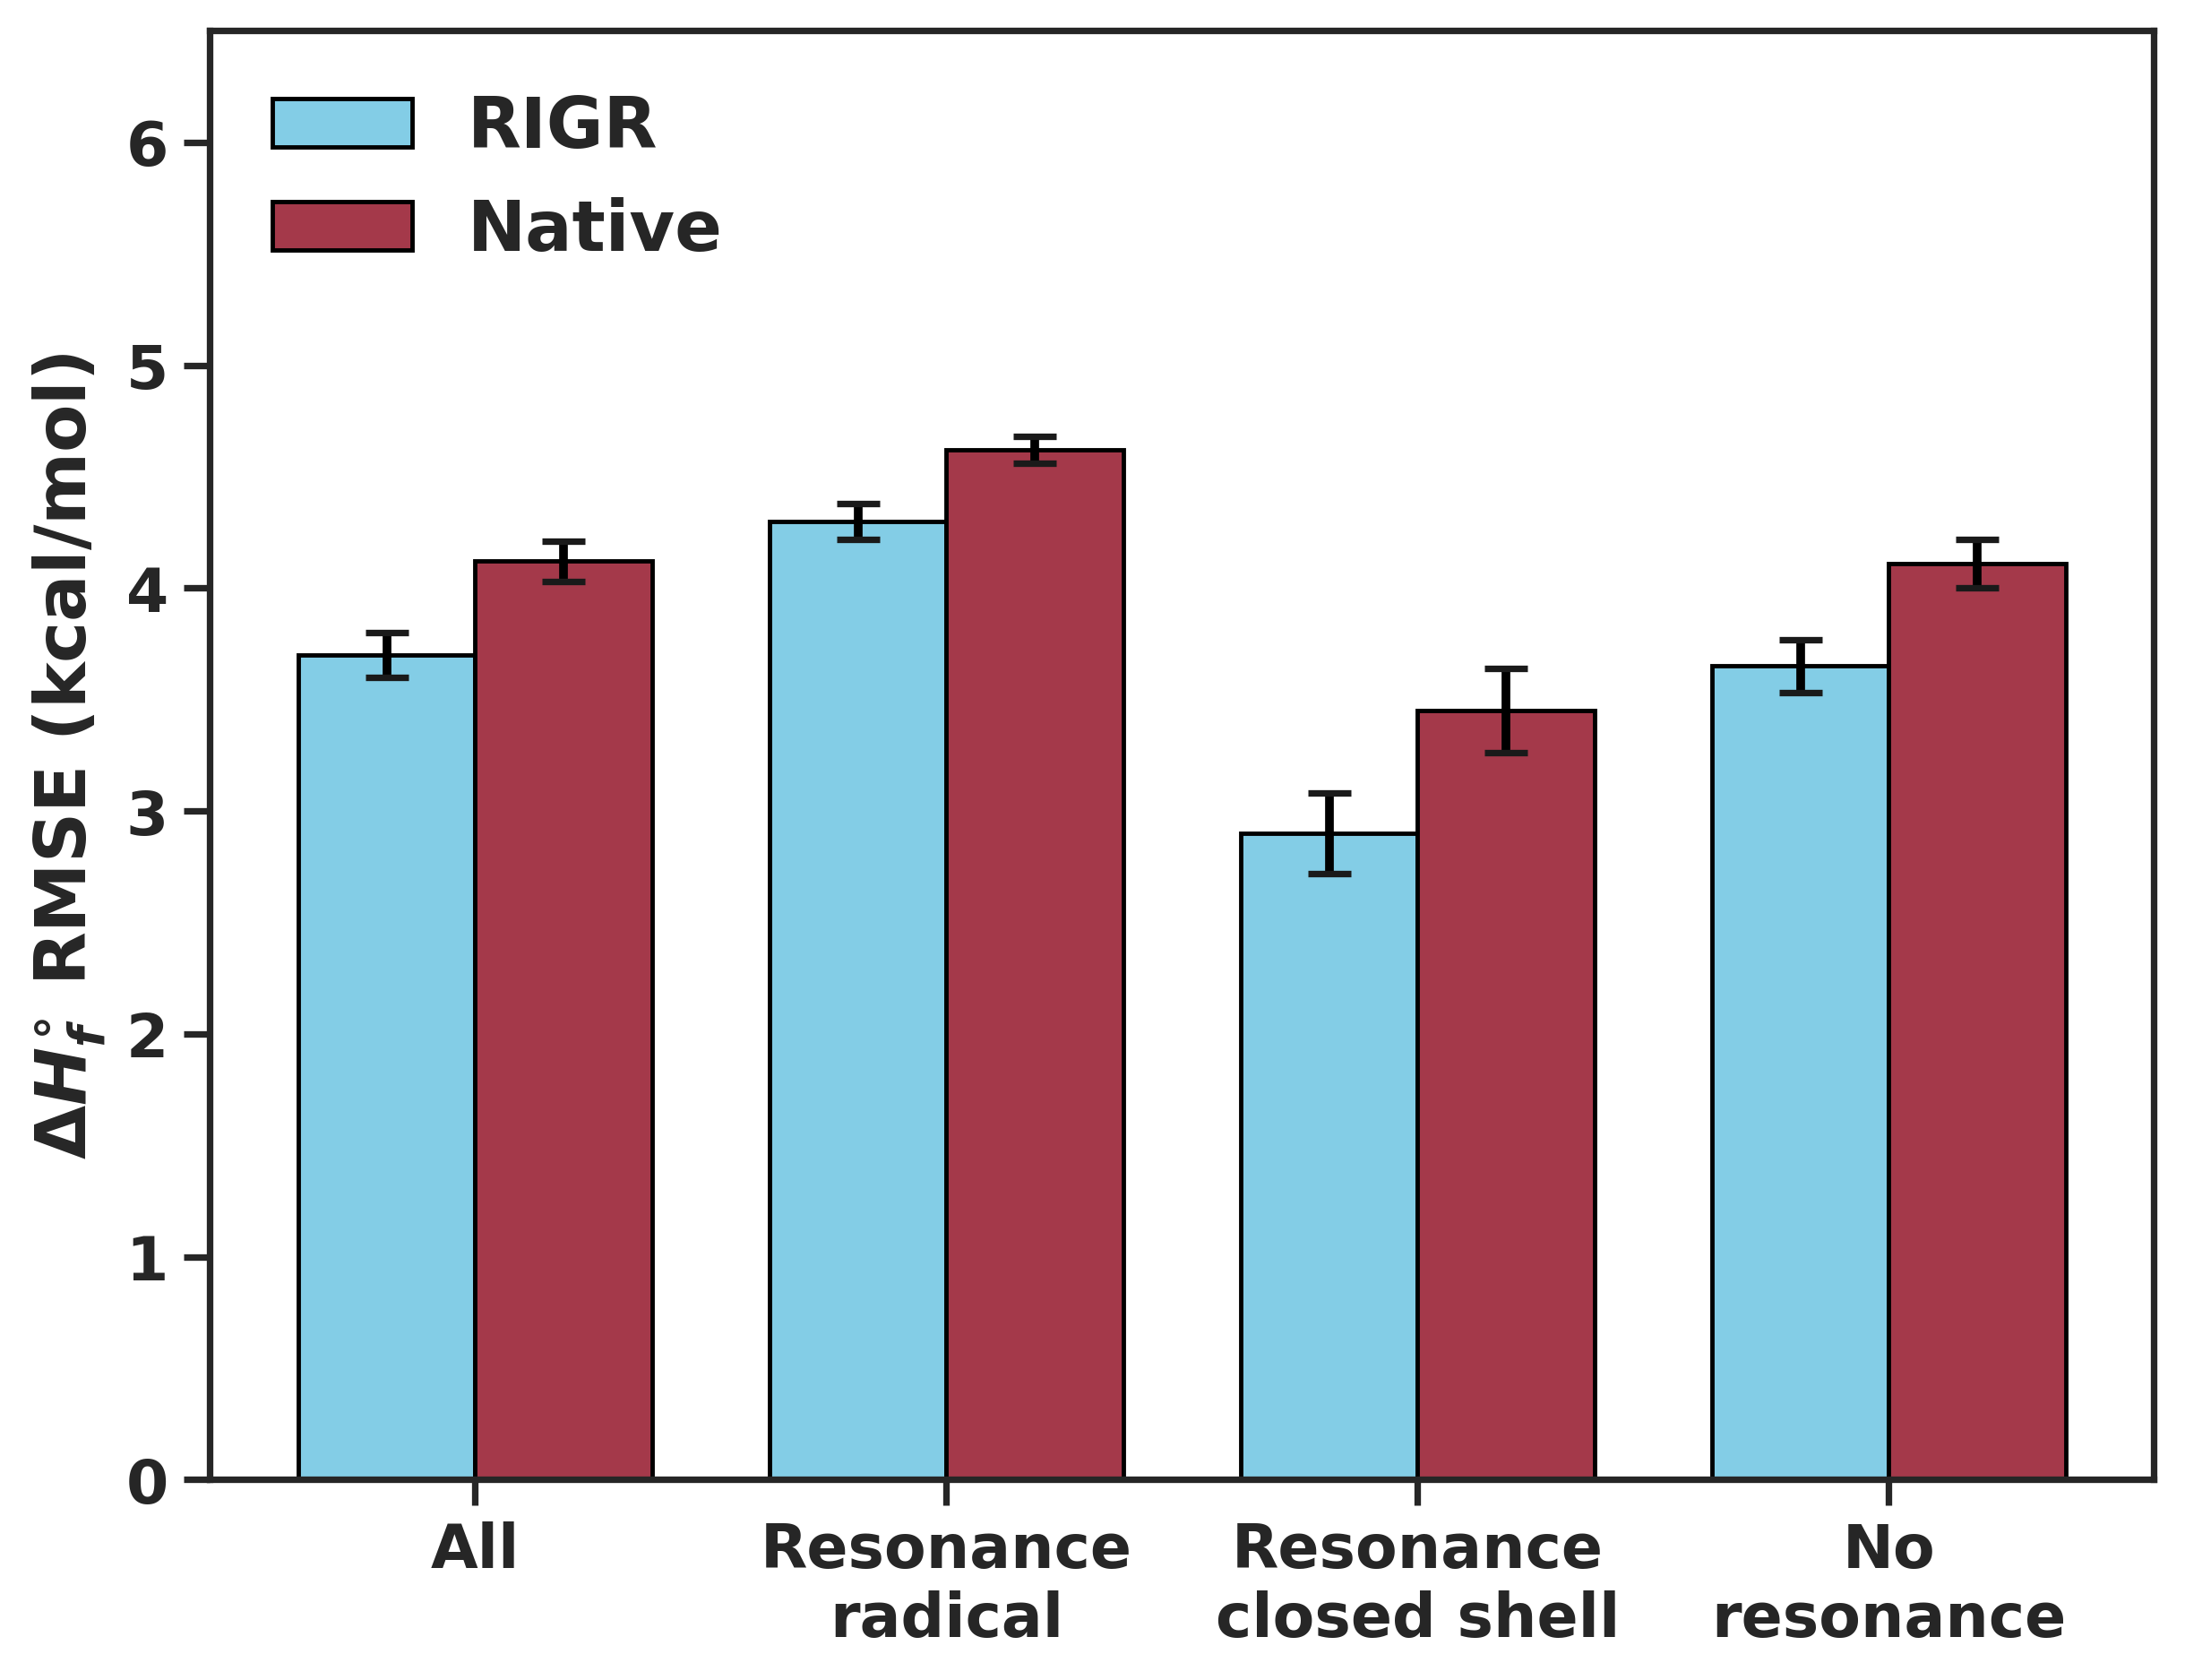

In [11]:
fig, ax1 = plt.subplots(1, 1, figsize=(8,6), dpi=350)

new_rc_params = {'text.usetex': False,
"svg.fonttype": 'none'
}
plt.rcParams.update(new_rc_params)


xs = np.arange(4)
width = 0.75/2
ax1.bar(
    xs,
    error_results["run1-bof"]["rmse"],
    yerr = error_results["run1-bof"]["rmse_err"],
    label="run1-bof",
    width=width,
    color=my_blue,
    edgecolor='black',
    ecolor='black',
    capsize= 5 ,
)
ax1.bar(
    xs + width,
    error_results["run1-baseline"]["rmse"],
    yerr = error_results["run1-baseline"]["rmse_err"],
    label = "run1-baseline",
    width = width,
    color= my_red,
    edgecolor='black',
    ecolor='black',
    capsize= 5 ,
)
# ax1.scatter(xs, np.array(error_results["run1-bof"]["rmse"])+0.5, marker='d', facecolors='none', edgecolors='black', s=180)
ax1.set_xticks([i+width/2 for i in range(4)], ["All", "Resonance\nradical", "Resonance\nclosed shell", "No\nresonance"])
ax1.set_ylabel(r"$\Delta H_{f}^{\circ}$ RMSE (kcal/mol)")
# ax1.set_xlabel("Category")
legend = ax1.legend(["RIGR", "Native"], loc = 'upper left', frameon=False, handlelength = 2)
ax1.set_ylim([0, 6.5])
ax1.set_yticks(np.arange(7))

fig.savefig("/home/akshatz/bond_order_free/figures/base_case.pdf", bbox_inches="tight")
# fig.savefig("/home/akshatz/bond_order_free/figures/f3.svg")

In [12]:
# fig, ax1 = plt.subplots(1, 1, figsize=(8,6), dpi=350)

# new_rc_params = {'text.usetex': False,
# "svg.fonttype": 'none'
# }
# plt.rcParams.update(new_rc_params)

# xs = np.arange(4)
# width = 0.75/2

# bof_bar = ax1.bar(
#     xs,
#     error_results["run1-bof"]["rmse"],
#     yerr=error_results["run1-bof"]["rmse_err"],
#     label="RIGR",  # Label for the legend
#     width=width,
#     color=my_blue,
#     edgecolor='black',
#     ecolor='black',
#     capsize=5,
# )

# baseline_bar = ax1.bar(
#     xs + width,
#     error_results["run1-baseline"]["rmse"],
#     yerr=error_results["run1-baseline"]["rmse_err"],
#     label="Native",  # Label for the legend
#     width=width,
#     color=my_red,
#     edgecolor='black',
#     ecolor='black',
#     capsize=5,
# )

# # Plot the scatter points
# p_value_marker = ax1.scatter(
#     xs, np.array(error_results["run1-bof"]["rmse"]) + np.array(error_results["run1-bof"]["rmse_err"]) + 0.25,
#     marker='*', s=300, facecolor='#D4AF37', edgecolors='black', label="${p} < 0.025$"
# )

# # Set the x-ticks
# ax1.set_xticks([i + width/2 for i in range(4)], ["All", "Resonance\nradical", "Resonance\nclosed shell", "No\nresonance"])
# ax1.set_ylabel(r"$\Delta H_{f}^{\circ}$ RMSE (kcal/mol)")
# ax1.set_ylim([0, 7.5])
# ax1.set_yticks(np.arange(8))

# # Manually create the legend, ensuring order is preserved
# legend = ax1.legend([bof_bar, baseline_bar, p_value_marker], ["RIGR", "Native", "$p<0.025$"], loc='upper left', frameon=False, handlelength=2)

# fig.savefig("/home/akshatz/bond_order_free/figures/base_case_p.pdf", bbox_inches="tight")

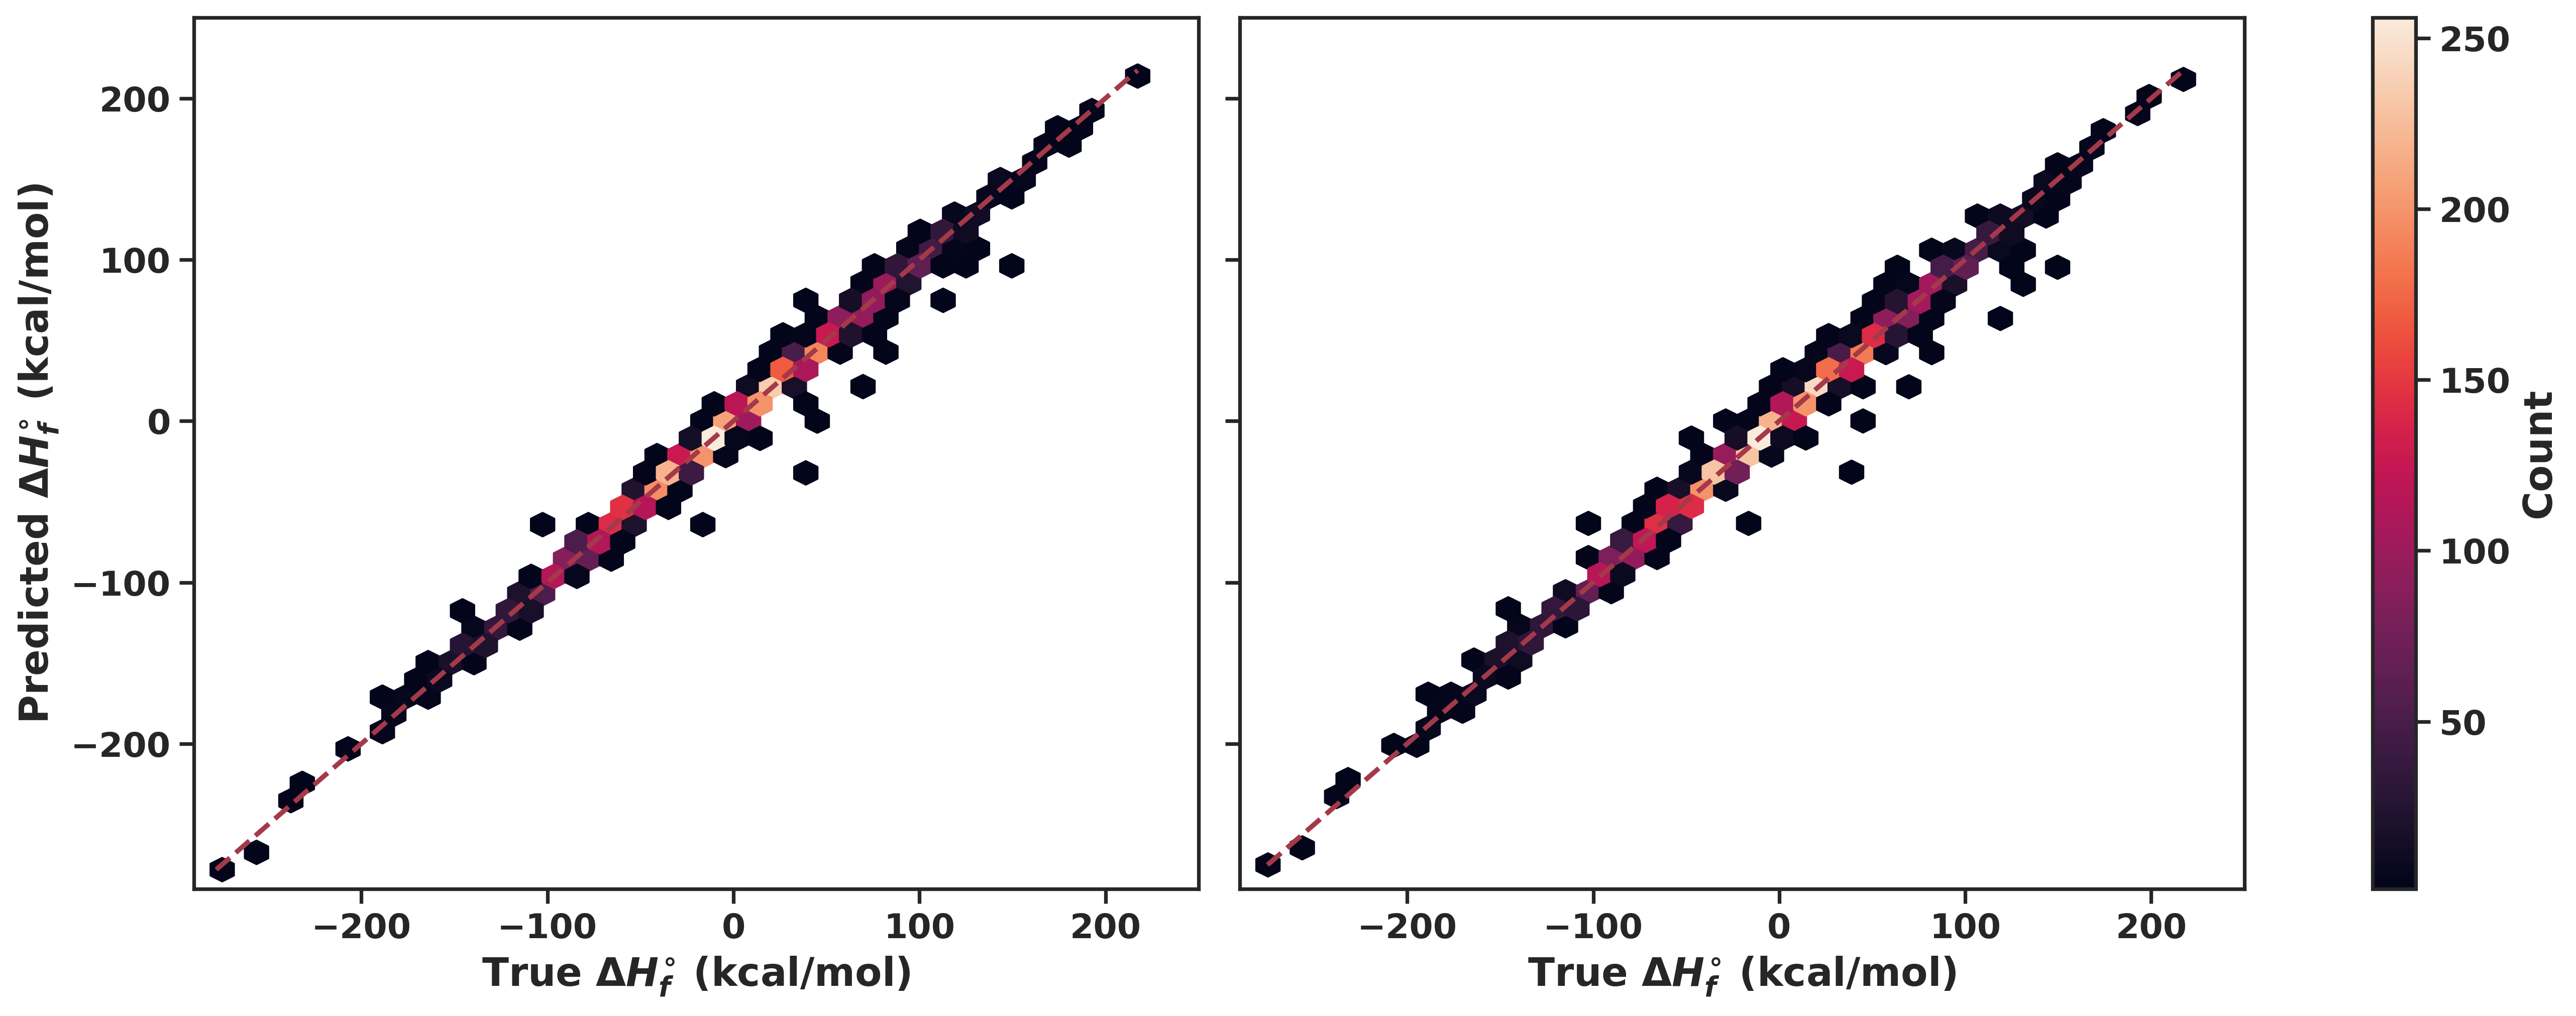

In [13]:
fig,axs = plt.subplots(ncols=2, figsize = (16,6), sharey=True, dpi=350)

df_avg1 = df_avg_dict["run1-bof"]
df_avg1["error"] = df_avg1["pred_0"]- df_avg1["H298_kcal"]
true_ys = df_avg1["H298_kcal"].values
pred_ys = df_avg1["pred_0"].values
pred_ys1 = pred_ys
im = axs[0].hexbin(true_ys, pred_ys, gridsize=40, mincnt=1)
min_x = np.min([true_ys.min(), pred_ys.min()])
max_x = np.max([true_ys.max(), pred_ys.max()])
axs[0].plot([min_x, max_x], [min_x, max_x], color=my_red, linestyle='--')
#plt.colorbar(im, label="Count", ax = axs[0])
axs[0].set_xlabel(r"True $\Delta H_{f}^{\circ}$ (kcal/mol)")
axs[0].set_ylabel(r"Predicted $\Delta H_{f}^{\circ}$ (kcal/mol)")
R2 = r2_score(true_ys, pred_ys)
MAE = error_results["run1-bof"]["mae"][0]
MAE_ERR = error_results["run1-bof"]["mae_err"][0]
RMSE = error_results["run1-bof"]["rmse"][0]
RMSE_ERR = error_results["run1-bof"]["rmse_err"][0]
# axs[0].text(0.1, 0.85, f"RMSE = {RMSE:.2f} ± {RMSE_ERR:.2f}"+"\n"+f"MAE   = {MAE:.2f} ± {MAE_ERR}"+"\n"+f"R$^2$      = {R2:.4f}", transform=axs[0].transAxes)
axs[0].set_xlim([-290, 250])
axs[0].set_ylim([-290, 250])


df_avg2 = df_avg_dict["run1-baseline"]
df_avg2["error"] = df_avg2["pred_0"]- df_avg2["H298_kcal"]
true_ys = df_avg2["H298_kcal"].values
pred_ys = df_avg2["pred_0"].values
pred_ys2 = pred_ys
im = axs[1].hexbin(true_ys, pred_ys, gridsize=40, mincnt=1)
min_x = np.min([true_ys.min(), pred_ys.min()])
max_x = np.max([true_ys.max(), pred_ys.max()])
axs[1].plot([min_x, max_x], [min_x, max_x], color=my_red, linestyle='--')

axs[1].set_xlabel(r"True $\Delta H_{f}^{\circ}$ (kcal/mol)")
#axs[1].set_ylabel(r"Predicted $\Delta H_{f}^{\circ}$ (kcal/mol)")
R2 = r2_score(true_ys, pred_ys)
MAE = error_results["run1-baseline"]["mae"][0]
MAE_ERR = error_results["run1-baseline"]["mae_err"][0]
RMSE = error_results["run1-baseline"]["rmse"][0]
RMSE_ERR = error_results["run1-baseline"]["rmse_err"][0]
# axs[1].text(0.1, 0.85, f"RMSE = {RMSE:.2f} ± {RMSE_ERR:.2f}"+"\n"+f"MAE   = {MAE:.2f} ± {MAE_ERR}"+"\n"+f"R$^2$      = {R2:.4f}", transform=axs[1].transAxes)
axs[1].set_xlim([-290, 250])

fig.tight_layout()
fig.colorbar(im, label="Count", ax = axs.ravel().tolist())
fig.savefig("/home/akshatz/bond_order_free/figures/pairity_base_case.pdf", bbox_inches="tight")

In [14]:
# import matplotlib.pyplot as plt
# import numpy as np
# from scipy.stats import gaussian_kde

# rigr_preds = df_avg1["pred_0"] - df_avg1["H298_kcal"]
# native_preds = df_avg2["pred_0"] - df_avg2["H298_kcal"]

# fig, ax1 = plt.subplots(figsize = (8,6), dpi =350)
# data_range = (min(rigr_preds), max(rigr_preds))

# # Assuming rigr_preds and native_preds are already defined

# ax1.hist(rigr_preds, bins=70, range = data_range , alpha=0.5, label='RIGR', color=my_blue)
# ax1.hist(native_preds, bins=70, range = data_range , alpha=0.5, label='Native', color=my_red)
# ax1.set_yscale('log')
# # # Create KDE for smooth curves
# # kde1 = gaussian_kde(rigr_preds)
# # kde2 = gaussian_kde(native_preds)

# # # Generate range for the KDE lines
# # x_vals = np.linspace(min(rigr_preds.min(), native_preds.min()), max(rigr_preds.max(), native_preds.max()), 1000)

# # # Plot KDE curves (optional)
# # plt.plot(x_vals, kde1(x_vals) * len(rigr_preds) * (max(rigr_preds.max(), native_preds.max()) - min(rigr_preds.min(), native_preds.min())) / 30, 
# #          label='RIGR KDE', color=my_blue)
# # plt.plot(x_vals, kde2(x_vals) * len(native_preds) * (max(rigr_preds.max(), native_preds.max()) - min(rigr_preds.min(), native_preds.min())) / 30, 
# #          label='Native KDE', color=my_red)

# # Add title and labels
# # plt.title('Distributions with KDE Curves')
# ax1.set_xlabel(r"Predicted $\Delta H_{f}^{\circ}$ (kcal/mol)")
# ax1.set_ylabel('Count')

# # Add legend with only two entries
# legend = ax1.legend(["RIGR", "Native"], loc = 'upper left', frameon=False, handlelength = 2)

# fig.savefig("/home/akshatz/bond_order_free/figures/distribution_comparison.pdf", bbox_inches="tight")

In [15]:
# fig, ax1 = plt.subplots(1, 1, figsize=(8,6), dpi=350)

# rigr_preds = df_avg1["pred_0"]
# native_preds = df_avg2["pred_0"]

# true_ys = rigr_preds
# pred_ys = native_preds

# # im = ax1.hexbin(true_ys, pred_ys, gridsize=40, mincnt=1)
# im = ax1.scatter(true_ys, pred_ys)
# min_x = np.min([true_ys.min(), pred_ys.min()])
# max_x = np.max([true_ys.max(), pred_ys.max()])
# ax1.plot([min_x, max_x], [min_x, max_x], color=my_red, linestyle='--')
# R2 = r2_score(true_ys, pred_ys)
# R2


In [16]:
# differences = rigr_preds - native_preds

# plt.hist(differences, bins=30, alpha=0.7)

# # Add labels and title
# plt.xlabel('Prediction Difference (Model 1 - Model 2)')
# plt.ylabel('Frequency')
# plt.title('Distribution of Prediction Differences')

# # Show the plot
# plt.show()

### chemprop on augmented test set

In [17]:
mae_lst_run2_baseline = []
rmse_lst_run2_baseline = []

mae_res_rad_lst_run2_baseline = []
rmse_res_rad_lst_run2_baseline = []
rmsrr_res_rad_lst_run2_baseline = []
rmsmrd_res_rad_lst_run2_baseline = []

mae_res_cs_lst_run2_baseline = []
rmse_res_cs_lst_run2_baseline = []
rmsrr_res_cs_lst_run2_baseline = []
rmsmrd_res_cs_lst_run2_baseline = []

mae_non_res_lst_run2_baseline = []
rmse_non_res_lst_run2_baseline = []


for i in range(5):
    df = pd.read_csv(f'run1_baseline_best/results_aug/test_preds_{i}.csv')
    df = df.merge(all_aug_data_set[["resonance_smis", "subset", "parent_smi"]], how="left", on="resonance_smis")
    y_true = df["H298_kcal"].values
    y_pred = df["pred_0"].values

    mae_lst_run2_baseline.append(mean_absolute_error(y_true, y_pred))
    rmse_lst_run2_baseline.append(np.sqrt(mean_squared_error(y_true, y_pred)))

    mae_res_rad_lst_run2_baseline.append(mean_absolute_error(df.loc[df['subset'] == 'res_radical', 'H298_kcal'], 
                                    df.loc[df['subset'] == 'res_radical', 'pred_0']))
    rmse_res_rad_lst_run2_baseline.append(np.sqrt(mean_squared_error(df.loc[df['subset'] == 'res_radical', 'H298_kcal'], 
                                    df.loc[df['subset'] == 'res_radical', 'pred_0'])))

    mae_res_cs_lst_run2_baseline.append(mean_absolute_error(df.loc[df['subset'] == 'res_closed_shell', 'H298_kcal'], 
                                    df.loc[df['subset'] == 'res_closed_shell', 'pred_0']))
    rmse_res_cs_lst_run2_baseline.append(np.sqrt(mean_squared_error(df.loc[df['subset'] == 'res_closed_shell', 'H298_kcal'], 
                                    df.loc[df['subset'] == 'res_closed_shell', 'pred_0'])))

    mae_non_res_lst_run2_baseline.append(mean_absolute_error(df.loc[df['subset'] == 'non_resonance', 'H298_kcal'], 
                                    df.loc[df['subset'] == 'non_resonance', 'pred_0']))
    rmse_non_res_lst_run2_baseline.append(np.sqrt(mean_squared_error(df.loc[df['subset'] == 'non_resonance', 'H298_kcal'], 
                                    df.loc[df['subset'] == 'non_resonance', 'pred_0'])))
    
    rmsrr_res_rad_lst_run2_baseline.append(compute_rmsrr(df.query('subset == "res_radical"'), 'pred_0','parent_smi'))
    rmsrr_res_cs_lst_run2_baseline.append(compute_rmsrr(df.query('subset == "res_closed_shell"'), 'pred_0','parent_smi'))

    rmsmrd_res_rad_lst_run2_baseline.append(compute_rmsmrd(df.query('subset == "res_radical"'), 'parent_smi', 'pred_0', 'H298_kcal'))
    rmsmrd_res_cs_lst_run2_baseline.append(compute_rmsmrd(df.query('subset == "res_closed_shell"'), 'parent_smi', 'pred_0', 'H298_kcal'))
    
    print(compute_rr_max(df.query('subset == "res_radical"'), 'pred_0', 'parent_smi'))
    if i == 0:
        df0 = df

# Mean and standard deviation for MAE and RMSE
mae = round(np.mean(mae_lst_run2_baseline), 2)
mae_err = round(np.std(mae_lst_run2_baseline), 2)
rmse = round(np.mean(rmse_lst_run2_baseline), 2)
rmse_err = round(np.std(rmse_lst_run2_baseline), 2)

# Mean and standard deviation for MAE, RMSE, MRR, MMRD for res_rad
mae_res_rad = round(np.mean(mae_res_rad_lst_run2_baseline), 2)
mae_res_rad_err = round(np.std(mae_res_rad_lst_run2_baseline), 2)
rmse_res_rad = round(np.mean(rmse_res_rad_lst_run2_baseline), 2)
rmse_res_rad_err = round(np.std(rmse_res_rad_lst_run2_baseline), 2)
rmsrr_res_rad = round(np.mean(rmsrr_res_rad_lst_run2_baseline), 2)
rmsrr_res_rad_err = round(np.std(rmsrr_res_rad_lst_run2_baseline), 2)
rmsmrd_res_rad = round(np.mean(rmsmrd_res_rad_lst_run2_baseline), 2)
rmsmrd_res_rad_err = round(np.std(rmsmrd_res_rad_lst_run2_baseline), 2)

# Mean and standard deviation for MAE, RMSE, MRR, MMRD for res_cs
mae_res_cs = round(np.mean(mae_res_cs_lst_run2_baseline), 2)
mae_res_cs_err = round(np.std(mae_res_cs_lst_run2_baseline), 2)
rmse_res_cs = round(np.mean(rmse_res_cs_lst_run2_baseline), 2)
rmse_res_cs_err = round(np.std(rmse_res_cs_lst_run2_baseline), 2)
rmsrr_res_cs = round(np.mean(rmsrr_res_cs_lst_run2_baseline), 2)
rmsrr_res_cs_err = round(np.std(rmsrr_res_cs_lst_run2_baseline), 2)
rmsmrd_res_cs = round(np.mean(rmsmrd_res_cs_lst_run2_baseline), 2)
rmsmrd_res_cs_err = round(np.std(rmsmrd_res_cs_lst_run2_baseline), 2)

# Mean and standard deviation for MAE and RMSE for non_res
mae_non_res = round(np.mean(mae_non_res_lst_run2_baseline), 2)
mae_non_res_err = round(np.std(mae_non_res_lst_run2_baseline), 2)
rmse_non_res = round(np.mean(rmse_non_res_lst_run2_baseline), 2)
rmse_non_res_err = round(np.std(rmse_non_res_lst_run2_baseline), 2)


error_results["run2-baseline"] = dict()
error_results["run2-baseline"]["mae"] = [mae, mae_res_rad, mae_res_cs, mae_non_res]
error_results["run2-baseline"]["mae_err"] = [mae_err, mae_res_rad_err, mae_res_cs_err, mae_non_res_err]
error_results["run2-baseline"]["rmse"] = [rmse, rmse_res_rad, rmse_res_cs, rmse_non_res]
error_results["run2-baseline"]["rmse_err"] = [rmse_err, rmse_res_rad_err, rmse_res_cs_err, rmse_non_res_err]
error_results["run2-baseline"]["rmsrr"] = [rmsrr_res_rad, rmsrr_res_cs]
error_results["run2-baseline"]["rmsrr_err"] = [rmsrr_res_rad_err, rmsrr_res_cs_err]
error_results["run2-baseline"]["rmsmrd"] = [rmsmrd_res_rad, rmsmrd_res_cs]
error_results["run2-baseline"]["rmsmrd_err"] = [rmsmrd_res_rad_err, rmsmrd_res_cs_err]
df_avg_dict["run2-baseline"] = df0

data = [
    ["all", f'{error_results["run2-baseline"]["mae"][0]:.2f} ± {error_results["run2-baseline"]["mae_err"][0]:.2f}', f'{error_results["run2-baseline"]["rmse"][0]:.2f} ± {error_results["run2-baseline"]["rmse_err"][0]:.2f}'],
    ["res_rad", f'{error_results["run2-baseline"]["mae"][1]:.2f} ± {error_results["run2-baseline"]["mae_err"][1]:.2f}', f'{error_results["run2-baseline"]["rmse"][1]:.2f} ± {error_results["run2-baseline"]["rmse_err"][1]:.2f}',f'{error_results["run2-baseline"]["rmsrr"][0]:.2f} ± {error_results["run2-baseline"]["rmsrr_err"][0]:.2f}', f'{error_results["run2-baseline"]["rmsmrd"][0]:.2f} ± {error_results["run2-baseline"]["rmsmrd_err"][0]:.2f}'],
    ["res_cs",f'{error_results["run2-baseline"]["mae"][2]:.2f} ± {error_results["run2-baseline"]["mae_err"][2]:.2f}', f'{error_results["run2-baseline"]["rmse"][2]:.2f} ± {error_results["run2-baseline"]["rmse_err"][2]:.2f}',f'{error_results["run2-baseline"]["rmsrr"][1]:.2f} ± {error_results["run2-baseline"]["rmsrr_err"][1]:.2f}', f'{error_results["run2-baseline"]["rmsmrd"][1]:.2f} ± {error_results["run2-baseline"]["rmsmrd_err"][1]:.2f}'],
    ["non_res", f'{error_results["run2-baseline"]["mae"][3]:.2f} ± {error_results["run2-baseline"]["mae_err"][3]:.2f}', f'{error_results["run2-baseline"]["rmse"][3]:.2f} ± {error_results["run2-baseline"]["rmse_err"][3]:.2f}'],
]

# Print the table
print("chemprop on augmented test:\n")
print(tabulate(data, headers=["Subset", "MAE", "RMSE", "RMSRR", "RMSMRD"]))

22.530065999999998
25.815120999999998
24.018501999999998
29.021105999999996
27.185551000000004
chemprop on augmented test:

Subset    MAE          RMSE         RMSRR        RMSMRD
--------  -----------  -----------  -----------  -----------
all       2.34 ± 0.06  3.99 ± 0.08
res_rad   2.40 ± 0.06  4.24 ± 0.07  2.96 ± 0.09  5.33 ± 0.09
res_cs    2.23 ± 0.08  3.57 ± 0.17  1.72 ± 0.04  4.02 ± 0.17
non_res   2.50 ± 0.07  4.11 ± 0.11


### rigr on augmented test set

In [18]:
mae_lst_run2_bof = []
rmse_lst_run2_bof = []

mae_res_rad_lst_run2_bof = []
rmse_res_rad_lst_run2_bof = []
rmsrr_res_rad_lst_run2_bof = []
rmsmrd_res_rad_lst_run2_bof = []

mae_res_cs_lst_run2_bof = []
rmse_res_cs_lst_run2_bof = []
rmsrr_res_cs_lst_run2_bof = []
rmsmrd_res_cs_lst_run2_bof = []

mae_non_res_lst_run2_bof = []
rmse_non_res_lst_run2_bof = []


for i in range(5):
    df = pd.read_csv(f'run1_bof_best/results_aug/test_preds_{i}.csv')
    df = df.merge(all_aug_data_set[["resonance_smis", "subset", "parent_smi"]], how="left", on="resonance_smis")
    y_true = df["H298_kcal"].values
    y_pred = df["pred_0"].values

    mae_lst_run2_bof.append(mean_absolute_error(y_true, y_pred))
    rmse_lst_run2_bof.append(np.sqrt(mean_squared_error(y_true, y_pred)))

    mae_res_rad_lst_run2_bof.append(mean_absolute_error(df.loc[df['subset'] == 'res_radical', 'H298_kcal'], 
                                    df.loc[df['subset'] == 'res_radical', 'pred_0']))
    rmse_res_rad_lst_run2_bof.append(np.sqrt(mean_squared_error(df.loc[df['subset'] == 'res_radical', 'H298_kcal'], 
                                    df.loc[df['subset'] == 'res_radical', 'pred_0'])))

    mae_res_cs_lst_run2_bof.append(mean_absolute_error(df.loc[df['subset'] == 'res_closed_shell', 'H298_kcal'], 
                                    df.loc[df['subset'] == 'res_closed_shell', 'pred_0']))
    rmse_res_cs_lst_run2_bof.append(np.sqrt(mean_squared_error(df.loc[df['subset'] == 'res_closed_shell', 'H298_kcal'], 
                                    df.loc[df['subset'] == 'res_closed_shell', 'pred_0'])))

    mae_non_res_lst_run2_bof.append(mean_absolute_error(df.loc[df['subset'] == 'non_resonance', 'H298_kcal'], 
                                    df.loc[df['subset'] == 'non_resonance', 'pred_0']))
    rmse_non_res_lst_run2_bof.append(np.sqrt(mean_squared_error(df.loc[df['subset'] == 'non_resonance', 'H298_kcal'], 
                                    df.loc[df['subset'] == 'non_resonance', 'pred_0'])))
    
    rmsrr_res_rad_lst_run2_bof.append(compute_rmsrr(df.query('subset == "res_radical"'), 'pred_0','parent_smi'))
    rmsrr_res_cs_lst_run2_bof.append(compute_rmsrr(df.query('subset == "res_closed_shell"'), 'pred_0','parent_smi'))

    rmsmrd_res_rad_lst_run2_bof.append(compute_rmsmrd(df.query('subset == "res_radical"'), 'parent_smi', 'pred_0', 'H298_kcal'))
    rmsmrd_res_cs_lst_run2_bof.append(compute_rmsmrd(df.query('subset == "res_closed_shell"'), 'parent_smi', 'pred_0', 'H298_kcal'))
    if i == 0:
        df0 = df

# Mean and standard deviation for MAE and RMSE
mae = round(np.mean(mae_lst_run2_bof), 2)
mae_err = round(np.std(mae_lst_run2_bof), 2)
rmse = round(np.mean(rmse_lst_run2_bof), 2)
rmse_err = round(np.std(rmse_lst_run2_bof), 2)

# Mean and standard deviation for MAE, RMSE, MRR, MMRD for res_rad
mae_res_rad = round(np.mean(mae_res_rad_lst_run2_bof), 2)
mae_res_rad_err = round(np.std(mae_res_rad_lst_run2_bof), 2)
rmse_res_rad = round(np.mean(rmse_res_rad_lst_run2_bof), 2)
rmse_res_rad_err = round(np.std(rmse_res_rad_lst_run2_bof), 2)
rmsrr_res_rad = round(np.mean(rmsrr_res_rad_lst_run2_bof), 2)
rmsrr_res_rad_err = round(np.std(rmsrr_res_rad_lst_run2_bof), 2)
rmsmrd_res_rad = round(np.mean(rmsmrd_res_rad_lst_run2_bof), 2)
rmsmrd_res_rad_err = round(np.std(rmsmrd_res_rad_lst_run2_bof), 2)

# Mean and standard deviation for MAE, RMSE, MRR, MMRD for res_cs
mae_res_cs = round(np.mean(mae_res_cs_lst_run2_bof), 2)
mae_res_cs_err = round(np.std(mae_res_cs_lst_run2_bof), 2)
rmse_res_cs = round(np.mean(rmse_res_cs_lst_run2_bof), 2)
rmse_res_cs_err = round(np.std(rmse_res_cs_lst_run2_bof), 2)
rmsrr_res_cs = round(np.mean(rmsrr_res_cs_lst_run2_bof), 2)
rmsrr_res_cs_err = round(np.std(rmsrr_res_cs_lst_run2_bof), 2)
rmsmrd_res_cs = round(np.mean(rmsmrd_res_cs_lst_run2_bof), 2)
rmsmrd_res_cs_err = round(np.std(rmsmrd_res_cs_lst_run2_bof), 2)

# Mean and standard deviation for MAE and RMSE for non_res
mae_non_res = round(np.mean(mae_non_res_lst_run2_bof), 2)
mae_non_res_err = round(np.std(mae_non_res_lst_run2_bof), 2)
rmse_non_res = round(np.mean(rmse_non_res_lst_run2_bof), 2)
rmse_non_res_err = round(np.std(rmse_non_res_lst_run2_bof), 2)


error_results["run2-bof"] = dict()
error_results["run2-bof"]["mae"] = [mae, mae_res_rad, mae_res_cs, mae_non_res]
error_results["run2-bof"]["mae_err"] = [mae_err, mae_res_rad_err, mae_res_cs_err, mae_non_res_err]
error_results["run2-bof"]["rmse"] = [rmse, rmse_res_rad, rmse_res_cs, rmse_non_res]
error_results["run2-bof"]["rmse_err"] = [rmse_err, rmse_res_rad_err, rmse_res_cs_err, rmse_non_res_err]
error_results["run2-bof"]["rmsrr"] = [rmsrr_res_rad, rmsrr_res_cs]
error_results["run2-bof"]["rmsrr_err"] = [rmsrr_res_rad_err, rmsrr_res_cs_err]
error_results["run2-bof"]["rmsmrd"] = [rmsmrd_res_rad, rmsmrd_res_cs]
error_results["run2-bof"]["rmsmrd_err"] = [rmsmrd_res_rad_err, rmsmrd_res_cs_err]
df_avg_dict["run2-bof"] = df0

data = [
    ["all", f'{error_results["run2-bof"]["mae"][0]:.2f} ± {error_results["run2-bof"]["mae_err"][0]:.2f}', f'{error_results["run2-bof"]["rmse"][0]:.2f} ± {error_results["run2-bof"]["rmse_err"][0]:.2f}'],
    ["res_rad", f'{error_results["run2-bof"]["mae"][1]:.2f} ± {error_results["run2-bof"]["mae_err"][1]:.2f}', f'{error_results["run2-bof"]["rmse"][1]:.2f} ± {error_results["run2-bof"]["rmse_err"][1]:.2f}',f'{error_results["run2-bof"]["rmsrr"][0]:.2f} ± {error_results["run2-bof"]["rmsrr_err"][0]:.2f}', f'{error_results["run2-bof"]["rmsmrd"][0]:.2f} ± {error_results["run2-bof"]["rmsmrd_err"][0]:.2f}'],
    ["res_cs",f'{error_results["run2-bof"]["mae"][2]:.2f} ± {error_results["run2-bof"]["mae_err"][2]:.2f}', f'{error_results["run2-bof"]["rmse"][2]:.2f} ± {error_results["run2-bof"]["rmse_err"][2]:.2f}',f'{error_results["run2-bof"]["rmsrr"][1]:.2f} ± {error_results["run2-bof"]["rmsrr_err"][1]:.2f}', f'{error_results["run2-bof"]["rmsmrd"][1]:.2f} ± {error_results["run2-bof"]["rmsmrd_err"][1]:.2f}'],
    ["non_res", f'{error_results["run2-bof"]["mae"][3]:.2f} ± {error_results["run2-bof"]["mae_err"][3]:.2f}', f'{error_results["run2-bof"]["rmse"][3]:.2f} ± {error_results["run2-bof"]["rmse_err"][3]:.2f}'],
]

# Print the table
print("RUN 2 RIGR:\n")
print(tabulate(data, headers=["Subset", "MAE", "RMSE", "RMSRR", "RMSMRD"]))

RUN 2 RIGR:

Subset    MAE          RMSE         RMSRR        RMSMRD
--------  -----------  -----------  -----------  -----------
all       2.03 ± 0.06  3.50 ± 0.10
res_rad   2.04 ± 0.05  3.84 ± 0.08  0.00 ± 0.00  4.30 ± 0.08
res_cs    2.00 ± 0.09  2.92 ± 0.16  0.00 ± 0.00  2.90 ± 0.18
non_res   2.17 ± 0.09  3.65 ± 0.12


### chemprop-aug on augmented test set

In [19]:
mae_lst_run4_baseline = []
rmse_lst_run4_baseline = []

mae_res_rad_lst_run4_baseline = []
rmse_res_rad_lst_run4_baseline = []
rmsrr_res_rad_lst_run4_baseline = []
rmsmrd_res_rad_lst_run4_baseline = []

mae_res_cs_lst_run4_baseline = []
rmse_res_cs_lst_run4_baseline = []
rmsrr_res_cs_lst_run4_baseline = []
rmsmrd_res_cs_lst_run4_baseline = []

mae_non_res_lst_run4_baseline = []
rmse_non_res_lst_run4_baseline = []


for i in range(5):
    df = pd.read_csv(f'run4_baseline_best/results_aug/test_preds_{i}.csv')
    df = df.merge(all_aug_data_set[["resonance_smis", "subset", "parent_smi"]], how="left", on="resonance_smis")
    y_true = df["H298_kcal"].values
    y_pred = df["pred_0"].values

    mae_lst_run4_baseline.append(mean_absolute_error(y_true, y_pred))
    rmse_lst_run4_baseline.append(np.sqrt(mean_squared_error(y_true, y_pred)))

    mae_res_rad_lst_run4_baseline.append(mean_absolute_error(df.loc[df['subset'] == 'res_radical', 'H298_kcal'], 
                                    df.loc[df['subset'] == 'res_radical', 'pred_0']))
    rmse_res_rad_lst_run4_baseline.append(np.sqrt(mean_squared_error(df.loc[df['subset'] == 'res_radical', 'H298_kcal'], 
                                    df.loc[df['subset'] == 'res_radical', 'pred_0'])))

    mae_res_cs_lst_run4_baseline.append(mean_absolute_error(df.loc[df['subset'] == 'res_closed_shell', 'H298_kcal'], 
                                    df.loc[df['subset'] == 'res_closed_shell', 'pred_0']))
    rmse_res_cs_lst_run4_baseline.append(np.sqrt(mean_squared_error(df.loc[df['subset'] == 'res_closed_shell', 'H298_kcal'], 
                                    df.loc[df['subset'] == 'res_closed_shell', 'pred_0'])))

    mae_non_res_lst_run4_baseline.append(mean_absolute_error(df.loc[df['subset'] == 'non_resonance', 'H298_kcal'], 
                                    df.loc[df['subset'] == 'non_resonance', 'pred_0']))
    rmse_non_res_lst_run4_baseline.append(np.sqrt(mean_squared_error(df.loc[df['subset'] == 'non_resonance', 'H298_kcal'], 
                                    df.loc[df['subset'] == 'non_resonance', 'pred_0'])))
    
    rmsrr_res_rad_lst_run4_baseline.append(compute_rmsrr(df.query('subset == "res_radical"'), 'pred_0','parent_smi'))
    rmsrr_res_cs_lst_run4_baseline.append(compute_rmsrr(df.query('subset == "res_closed_shell"'), 'pred_0','parent_smi'))

    rmsmrd_res_rad_lst_run4_baseline.append(compute_rmsmrd(df.query('subset == "res_radical"'), 'parent_smi', 'pred_0', 'H298_kcal'))
    rmsmrd_res_cs_lst_run4_baseline.append(compute_rmsmrd(df.query('subset == "res_closed_shell"'), 'parent_smi', 'pred_0', 'H298_kcal'))
    if i == 0:
        df0 = df

# Mean and standard deviation for MAE and RMSE
mae = round(np.mean(mae_lst_run4_baseline), 2)
mae_err = round(np.std(mae_lst_run4_baseline), 2)
rmse = round(np.mean(rmse_lst_run4_baseline), 2)
rmse_err = round(np.std(rmse_lst_run4_baseline), 2)

# Mean and standard deviation for MAE, RMSE, MRR, MMRD for res_rad
mae_res_rad = round(np.mean(mae_res_rad_lst_run4_baseline), 2)
mae_res_rad_err = round(np.std(mae_res_rad_lst_run4_baseline), 2)
rmse_res_rad = round(np.mean(rmse_res_rad_lst_run4_baseline), 2)
rmse_res_rad_err = round(np.std(rmse_res_rad_lst_run4_baseline), 2)
rmsrr_res_rad = round(np.mean(rmsrr_res_rad_lst_run4_baseline), 2)
rmsrr_res_rad_err = round(np.std(rmsrr_res_rad_lst_run4_baseline), 2)
rmsmrd_res_rad = round(np.mean(rmsmrd_res_rad_lst_run4_baseline), 2)
rmsmrd_res_rad_err = round(np.std(rmsmrd_res_rad_lst_run4_baseline), 2)

# Mean and standard deviation for MAE, RMSE, MRR, MMRD for res_cs
mae_res_cs = round(np.mean(mae_res_cs_lst_run4_baseline), 2)
mae_res_cs_err = round(np.std(mae_res_cs_lst_run4_baseline), 2)
rmse_res_cs = round(np.mean(rmse_res_cs_lst_run4_baseline), 2)
rmse_res_cs_err = round(np.std(rmse_res_cs_lst_run4_baseline), 2)
rmsrr_res_cs = round(np.mean(rmsrr_res_cs_lst_run4_baseline), 2)
rmsrr_res_cs_err = round(np.std(rmsrr_res_cs_lst_run4_baseline), 2)
rmsmrd_res_cs = round(np.mean(rmsmrd_res_cs_lst_run4_baseline), 2)
rmsmrd_res_cs_err = round(np.std(rmsmrd_res_cs_lst_run4_baseline), 2)

# Mean and standard deviation for MAE and RMSE for non_res
mae_non_res = round(np.mean(mae_non_res_lst_run4_baseline), 2)
mae_non_res_err = round(np.std(mae_non_res_lst_run4_baseline), 2)
rmse_non_res = round(np.mean(rmse_non_res_lst_run4_baseline), 2)
rmse_non_res_err = round(np.std(rmse_non_res_lst_run4_baseline), 2)


error_results["run4-baseline"] = dict()
error_results["run4-baseline"]["mae"] = [mae, mae_res_rad, mae_res_cs, mae_non_res]
error_results["run4-baseline"]["mae_err"] = [mae_err, mae_res_rad_err, mae_res_cs_err, mae_non_res_err]
error_results["run4-baseline"]["rmse"] = [rmse, rmse_res_rad, rmse_res_cs, rmse_non_res]
error_results["run4-baseline"]["rmse_err"] = [rmse_err, rmse_res_rad_err, rmse_res_cs_err, rmse_non_res_err]
error_results["run4-baseline"]["rmsrr"] = [rmsrr_res_rad, rmsrr_res_cs]
error_results["run4-baseline"]["rmsrr_err"] = [rmsrr_res_rad_err, rmsrr_res_cs_err]
error_results["run4-baseline"]["rmsmrd"] = [rmsmrd_res_rad, rmsmrd_res_cs]
error_results["run4-baseline"]["rmsmrd_err"] = [rmsmrd_res_rad_err, rmsmrd_res_cs_err]
df_avg_dict["run4-baseline"] = df0

data = [
    ["all", f'{error_results["run4-baseline"]["mae"][0]:.2f} ± {error_results["run4-baseline"]["mae_err"][0]:.2f}', f'{error_results["run4-baseline"]["rmse"][0]:.2f} ± {error_results["run4-baseline"]["rmse_err"][0]:.2f}'],
    ["res_rad", f'{error_results["run4-baseline"]["mae"][1]:.2f} ± {error_results["run4-baseline"]["mae_err"][1]:.2f}', f'{error_results["run4-baseline"]["rmse"][1]:.2f} ± {error_results["run4-baseline"]["rmse_err"][1]:.2f}',f'{error_results["run4-baseline"]["rmsrr"][0]:.2f} ± {error_results["run4-baseline"]["rmsrr_err"][0]:.2f}', f'{error_results["run4-baseline"]["rmsmrd"][0]:.2f} ± {error_results["run4-baseline"]["rmsmrd_err"][0]:.2f}'],
    ["res_cs",f'{error_results["run4-baseline"]["mae"][2]:.2f} ± {error_results["run4-baseline"]["mae_err"][2]:.2f}', f'{error_results["run4-baseline"]["rmse"][2]:.2f} ± {error_results["run4-baseline"]["rmse_err"][2]:.2f}',f'{error_results["run4-baseline"]["rmsrr"][1]:.2f} ± {error_results["run4-baseline"]["rmsrr_err"][1]:.2f}', f'{error_results["run4-baseline"]["rmsmrd"][1]:.2f} ± {error_results["run4-baseline"]["rmsmrd_err"][1]:.2f}'],
    ["non_res", f'{error_results["run4-baseline"]["mae"][3]:.2f} ± {error_results["run4-baseline"]["mae_err"][3]:.2f}', f'{error_results["run4-baseline"]["rmse"][3]:.2f} ± {error_results["run4-baseline"]["rmse_err"][3]:.2f}'],
]

# Print the table
print("RUN 4 Baseline:\n")
print(tabulate(data, headers=["Subset", "MAE", "RMSE", "RMSRR", "RMSMRD"]))

RUN 4 Baseline:

Subset    MAE          RMSE         RMSRR        RMSMRD
--------  -----------  -----------  -----------  -----------
all       1.98 ± 0.04  3.39 ± 0.06
res_rad   1.99 ± 0.04  3.71 ± 0.05  1.36 ± 0.05  4.42 ± 0.07
res_cs    1.95 ± 0.06  2.82 ± 0.13  0.62 ± 0.03  2.92 ± 0.15
non_res   2.11 ± 0.04  3.61 ± 0.05


In [20]:
import pandas as pd
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests

def perform_pairwise_comparisons(models, model_names, alpha=0.05):
    """
    Function to perform pairwise t-tests on multiple models and return a DataFrame with mean differences,
    raw p-values, adjusted p-values (Bonferroni), and significance status.

    Parameters:
    - models: List of model data (each element should be a list of model values).
    - model_names: List of names for each model (corresponding to the order in 'models').
    - alpha: Significance level for determining if the results are statistically significant.

    Returns:
    - DataFrame with the following columns: Comparison, Mean Difference, Raw p-value, Adjusted p-value, Significant?
    """
    # Check if the number of models and names match
    if len(models) != len(model_names):
        raise ValueError("Number of models must match the number of model names.")

    # Initialize lists to store results
    pairs = [(model_names[i], model_names[j]) for i in range(len(models)) for j in range(i+1, len(models))]
    p_values = []
    mean_differences = []

    # Perform pairwise t-tests and calculate mean differences
    for i in range(len(models)):
        for j in range(i + 1, len(models)):
            t_stat, p_val = ttest_rel(models[i], models[j])
            mean_diff = sum(a - b for a, b in zip(models[i], models[j])) / len(models[i])
            p_values.append(p_val)
            mean_differences.append(mean_diff)

    # Apply Bonferroni correction to p-values
    adjusted_p_values = multipletests(p_values, method='bonferroni')[1]
    adjusted_p_values_scientific = [f"{p:.2e}" for p in adjusted_p_values]

    # Create a DataFrame for the results
    results_df = pd.DataFrame({
        'Comparison': [f"{pair[0]} - {pair[1]}" for pair in pairs],
        'Mean Difference': mean_differences,
        'Raw p-value': p_values,
        'Adjusted p-value': adjusted_p_values_scientific,
        'Significant?': ['Yes' if p < alpha/2 else 'No' for p in adjusted_p_values]
    })

    return results_df

In [21]:
model1 = rmse_lst_run2_bof
model2 = rmse_lst_run2_baseline
model3 = rmse_lst_run4_baseline
models = [model1, model2, model3]
model_names = ['rigr', 'native', 'native+aug']
results_df = perform_pairwise_comparisons(models, model_names)
print("RMSE all")
display(results_df)
# Extract the adjusted p-values in scientific notation
adjusted_p_values_scientific = results_df['Adjusted p-value'].apply(lambda x: f"${float(x):.2e}".replace("e", r"\times10^{") + "}$")

# Join the formatted p-values with '&' in between them
formatted_values = ' & '.join(adjusted_p_values_scientific)

# Print the values in the desired format
print(formatted_values)

RMSE all


,Comparison,Mean Difference,Raw p-value,Adjusted p-value,Significant?
0,rigr - native,-0.486492,0.000073,2.19e-04,Yes
1,rigr - native+aug,0.110312,0.021433,6.43e-02,No
2,native - native+aug,0.596805,0.000011,3.26e-05,Yes


$2.19\times10^{-04}$ & $6.43\times10^{-02}$ & $3.26\times10^{-05}$


In [22]:
model1 = rmse_res_rad_lst_run2_bof
model2 = rmse_res_rad_lst_run2_baseline
model3 = rmse_res_rad_lst_run4_baseline
models = [model1, model2, model3]
model_names = ['rigr', 'native', 'native+aug']
results_df = perform_pairwise_comparisons(models, model_names)
print("RMSE res rad")
display(results_df)
# Extract the adjusted p-values in scientific notation
adjusted_p_values_scientific = results_df['Adjusted p-value'].apply(lambda x: f"${float(x):.2e}".replace("e", r"\times10^{") + "}$")

# Join the formatted p-values with '&' in between them
formatted_values = ' & '.join(adjusted_p_values_scientific)

# Print the values in the desired format
print(formatted_values)

RMSE res rad


,Comparison,Mean Difference,Raw p-value,Adjusted p-value,Significant?
0,rigr - native,-0.401952,0.000329,9.87e-04,Yes
1,rigr - native+aug,0.128781,0.025017,7.51e-02,No
2,native - native+aug,0.530733,0.000004,1.30e-05,Yes


$9.87\times10^{-04}$ & $7.51\times10^{-02}$ & $1.30\times10^{-05}$


In [23]:
model1 = rmse_res_cs_lst_run2_bof
model2 = rmse_res_cs_lst_run2_baseline
model3 = rmse_res_cs_lst_run4_baseline
models = [model1, model2, model3]
model_names = ['rigr', 'native', 'native+aug']
results_df = perform_pairwise_comparisons(models, model_names)
print("RMSE res cs")
display(results_df)
# Extract the adjusted p-values in scientific notation
adjusted_p_values_scientific = results_df['Adjusted p-value'].apply(lambda x: f"${float(x):.2e}".replace("e", r"\times10^{") + "}$")

# Join the formatted p-values with '&' in between them
formatted_values = ' & '.join(adjusted_p_values_scientific)

# Print the values in the desired format
print(formatted_values)

RMSE res cs


,Comparison,Mean Difference,Raw p-value,Adjusted p-value,Significant?
0,rigr - native,-0.652107,0.000088,2.63e-04,Yes
1,rigr - native+aug,0.097312,0.023373,7.01e-02,No
2,native - native+aug,0.749419,0.000014,4.16e-05,Yes


$2.63\times10^{-04}$ & $7.01\times10^{-02}$ & $4.16\times10^{-05}$


In [24]:
model1 = rmse_non_res_lst_run2_bof
model2 = rmse_non_res_lst_run2_baseline
model3 = rmse_non_res_lst_run4_baseline
models = [model1, model2, model3]
model_names = ['rigr', 'native', 'native+aug']
results_df = perform_pairwise_comparisons(models, model_names)
print("RMSE non res")
display(results_df)
# Extract the adjusted p-values in scientific notation
adjusted_p_values_scientific = results_df['Adjusted p-value'].apply(lambda x: f"${float(x):.2e}".replace("e", r"\times10^{") + "}$")

# Join the formatted p-values with '&' in between them
formatted_values = ' & '.join(adjusted_p_values_scientific)

# Print the values in the desired format
print(formatted_values)

RMSE non res


,Comparison,Mean Difference,Raw p-value,Adjusted p-value,Significant?
0,rigr - native,-0.456590,0.000167,5.00e-04,Yes
1,rigr - native+aug,0.040791,0.388168,1.00e+00,No
2,native - native+aug,0.497381,0.000287,8.61e-04,Yes


$5.00\times10^{-04}$ & $1.00\times10^{+00}$ & $8.61\times10^{-04}$


In [25]:
model1 = rmsrr_res_rad_lst_run2_bof
model2 = rmsrr_res_rad_lst_run2_baseline
model3 = rmsrr_res_rad_lst_run4_baseline
models = [model1, model2, model3]
model_names = ['rigr', 'native', 'native+aug']
results_df = perform_pairwise_comparisons(models, model_names)
print("RMSRR res rad")
display(results_df)
# Extract the adjusted p-values in scientific notation
adjusted_p_values_scientific = results_df['Adjusted p-value'].apply(lambda x: f"${float(x):.2e}".replace("e", r"\times10^{") + "}$")

# Join the formatted p-values with '&' in between them
formatted_values = ' & '.join(adjusted_p_values_scientific)

# Print the values in the desired format
print(formatted_values)

RMSRR res rad


,Comparison,Mean Difference,Raw p-value,Adjusted p-value,Significant?
0,rigr - native,-2.960019,3.788647e-07,1.14e-06,Yes
1,rigr - native+aug,-1.364427,7.914092e-07,2.37e-06,Yes
2,native - native+aug,1.595592,4.370231e-06,1.31e-05,Yes


$1.14\times10^{-06}$ & $2.37\times10^{-06}$ & $1.31\times10^{-05}$


In [26]:
model1 = rmsrr_res_cs_lst_run2_bof
model2 = rmsrr_res_cs_lst_run2_baseline
model3 = rmsrr_res_cs_lst_run4_baseline
models = [model1, model2, model3]
model_names = ['rigr', 'native', 'native+aug']
results_df = perform_pairwise_comparisons(models, model_names)
print("RMSRR res cs")
display(results_df)
# Extract the adjusted p-values in scientific notation
adjusted_p_values_scientific = results_df['Adjusted p-value'].apply(lambda x: f"${float(x):.2e}".replace("e", r"\times10^{") + "}$")

# Join the formatted p-values with '&' in between them
formatted_values = ' & '.join(adjusted_p_values_scientific)

# Print the values in the desired format
print(formatted_values)

RMSRR res cs


,Comparison,Mean Difference,Raw p-value,Adjusted p-value,Significant?
0,rigr - native,-1.718834,1.295046e-07,3.89e-07,Yes
1,rigr - native+aug,-0.616528,1.578622e-06,4.74e-06,Yes
2,native - native+aug,1.102306,9.598816e-07,2.88e-06,Yes


$3.89\times10^{-07}$ & $4.74\times10^{-06}$ & $2.88\times10^{-06}$


In [27]:
model1 = rmsmrd_res_rad_lst_run2_bof
model2 = rmsmrd_res_rad_lst_run2_baseline
model3 = rmsmrd_res_rad_lst_run4_baseline
models = [model1, model2, model3]
model_names = ['rigr', 'native', 'native+aug']
results_df = perform_pairwise_comparisons(models, model_names)
print("RMSMRD res rad")
display(results_df)
# Extract the adjusted p-values in scientific notation
adjusted_p_values_scientific = results_df['Adjusted p-value'].apply(lambda x: f"${float(x):.2e}".replace("e", r"\times10^{") + "}$")

# Join the formatted p-values with '&' in between them
formatted_values = ' & '.join(adjusted_p_values_scientific)

# Print the values in the desired format
print(formatted_values)

RMSMRD res rad


,Comparison,Mean Difference,Raw p-value,Adjusted p-value,Significant?
0,rigr - native,-1.032058,0.000008,2.36e-05,Yes
1,rigr - native+aug,-0.122750,0.043811,1.31e-01,No
2,native - native+aug,0.909308,0.000002,7.18e-06,Yes


$2.36\times10^{-05}$ & $1.31\times10^{-01}$ & $7.18\times10^{-06}$


In [28]:
model1 = rmsmrd_res_cs_lst_run2_bof
model2 = rmsmrd_res_cs_lst_run2_baseline
model3 = rmsmrd_res_cs_lst_run4_baseline
models = [model1, model2, model3]
model_names = ['rigr', 'native', 'native+aug']
results_df = perform_pairwise_comparisons(models, model_names)
print("RMSMRD res cs")
display(results_df)
# Extract the adjusted p-values in scientific notation
adjusted_p_values_scientific = results_df['Adjusted p-value'].apply(lambda x: f"${float(x):.2e}".replace("e", r"\times10^{") + "}$")

# Join the formatted p-values with '&' in between them
formatted_values = ' & '.join(adjusted_p_values_scientific)

# Print the values in the desired format
print(formatted_values)

RMSMRD res cs


,Comparison,Mean Difference,Raw p-value,Adjusted p-value,Significant?
0,rigr - native,-1.122050,0.000012,3.65e-05,Yes
1,rigr - native+aug,-0.027506,0.265888,7.98e-01,No
2,native - native+aug,1.094544,0.000006,1.75e-05,Yes


$3.65\times10^{-05}$ & $7.98\times10^{-01}$ & $1.75\times10^{-05}$


In [29]:
# import pandas as pd
# from scipy.stats import ttest_rel

# # Perform t-tests and compute p-values
# t_statistic_rmsmrd_res_rad, p_value_rmsmrd_res_rad = ttest_rel(rmsmrd_res_rad_lst_run4_baseline, rmsmrd_res_rad_lst_run2_bof)
# t_statistic_rmsmrd_res_cs, p_value_rmsmrd_res_cs = ttest_rel(rmsmrd_res_cs_lst_run4_baseline, rmsmrd_res_cs_lst_run2_bof)

# # Determine if the results are statistically different
# alpha = 0.05
# difference_res_rad = "Y" if p_value_rmsmrd_res_rad <= alpha/2 else "N"
# difference_res_cs = "Y" if p_value_rmsmrd_res_cs <= alpha/2 else "N"

# # Construct the DataFrame
# data = {
#     "Subset": ["res_rad", "res_cs"],
#     "rmsmrd-RIGR": [
#         f'{error_results["run2-bof"]["rmsmrd"][0]:.2f} ± {error_results["run2-bof"]["rmsmrd_err"][0]:.2f}',
#         f'{error_results["run2-bof"]["rmsmrd"][1]:.2f} ± {error_results["run2-bof"]["rmsmrd_err"][1]:.2f}',
#     ],
#     "rmsmrd-Native": [
#         f'{error_results["run2-baseline"]["rmsmrd"][0]:.2f} ± {error_results["run2-baseline"]["rmsmrd_err"][0]:.2f}',
#         f'{error_results["run2-baseline"]["rmsmrd"][1]:.2f} ± {error_results["run2-baseline"]["rmsmrd_err"][1]:.2f}',
#     ],
#         "rmsmrd-Native-Aug": [
#         f'{error_results["run4-baseline"]["rmsmrd"][0]:.2f} ± {error_results["run4-baseline"]["rmsmrd_err"][0]:.2f}',
#         f'{error_results["run4-baseline"]["rmsmrd"][1]:.2f} ± {error_results["run4-baseline"]["rmsmrd_err"][1]:.2f}',
#     ],
    
#     "p-value": [p_value_rmsmrd_res_rad, p_value_rmsmrd_res_cs],
#     "different rmsmrd": [difference_res_rad, difference_res_cs]
# }

# tab4 = pd.DataFrame(data)
# tab4

In [30]:
# import pandas as pd
# from scipy.stats import ttest_rel

# # Perform t-tests and compute p-values
# t_statistic_rmsrr_res_rad, p_value_rmsrr_res_rad = ttest_rel(rmsrr_res_rad_lst_run4_baseline, rmsrr_res_rad_lst_run2_bof)
# t_statistic_rmsrr_res_cs, p_value_rmsrr_res_cs = ttest_rel(rmsrr_res_cs_lst_run4_baseline, rmsrr_res_cs_lst_run2_bof)

# # Determine if the results are statistically different
# alpha = 0.05
# difference_res_rad = "Y" if p_value_rmsrr_res_rad <= alpha/2 else "N"
# difference_res_cs = "Y" if p_value_rmsrr_res_cs <= alpha/2 else "N"

# # Construct the DataFrame
# data = {
#     "Subset": ["res_rad", "res_cs"],
#     "rmsrr-RIGR": [
#         f'{error_results["run2-bof"]["rmsrr"][0]:.2f} ± {error_results["run2-bof"]["rmsrr_err"][0]:.2f}',
#         f'{error_results["run2-bof"]["rmsrr"][1]:.2f} ± {error_results["run2-bof"]["rmsrr_err"][1]:.2f}',
#     ],
#     "rmsrr-Native": [
#         f'{error_results["run2-baseline"]["rmsrr"][0]:.2f} ± {error_results["run2-baseline"]["rmsrr_err"][0]:.2f}',
#         f'{error_results["run2-baseline"]["rmsrr"][1]:.2f} ± {error_results["run2-baseline"]["rmsrr_err"][1]:.2f}',
#     ],
#         "rmsrr-Native-Aug": [
#         f'{error_results["run4-baseline"]["rmsrr"][0]:.2f} ± {error_results["run4-baseline"]["rmsrr_err"][0]:.2f}',
#         f'{error_results["run4-baseline"]["rmsrr"][1]:.2f} ± {error_results["run4-baseline"]["rmsrr_err"][1]:.2f}',
#     ],
    
#     "p-value": [p_value_rmsrr_res_rad, p_value_rmsrr_res_cs],
#     "different rmsrr": [difference_res_rad, difference_res_cs]
# }

# tab3 = pd.DataFrame(data)
# tab3

In [31]:
# import pandas as pd
# from scipy.stats import ttest_rel

# # Perform t-tests and compute p-values
# t_statistic_rmse_all, p_value_rmse_all = ttest_rel(rmse_lst_run4_baseline, rmse_lst_run2_bof)
# t_statistic_rmse_res_rad, p_value_rmse_res_rad = ttest_rel(rmse_res_rad_lst_run4_baseline, rmse_res_rad_lst_run2_bof)
# t_statistic_rmse_res_cs, p_value_rmse_res_cs = ttest_rel(rmse_res_cs_lst_run4_baseline, rmse_res_cs_lst_run2_bof)
# t_statistic_rmse_non_res, p_value_rmse_non_res = ttest_rel(rmse_non_res_lst_run4_baseline, rmse_non_res_lst_run2_bof)

# # Determine if the results are statistically different
# alpha = 0.05
# difference_all = "Y" if p_value_rmse_all <= alpha/2 else "N"
# difference_res_rad = "Y" if p_value_rmse_res_rad <= alpha/2 else "N"
# difference_res_cs = "Y" if p_value_rmse_res_cs <= alpha/2 else "N"
# difference_non_res = "Y" if p_value_rmse_non_res <= alpha/2 else "N"

# # Construct the DataFrame
# data = {
#     "Subset": ["all", "res_rad", "res_cs", "non_res"],
#     "RMSE-RIGR": [
#         f'{error_results["run2-bof"]["rmse"][0]:.2f} ± {error_results["run2-bof"]["rmse_err"][0]:.2f}',
#         f'{error_results["run2-bof"]["rmse"][1]:.2f} ± {error_results["run2-bof"]["rmse_err"][1]:.2f}',
#         f'{error_results["run2-bof"]["rmse"][2]:.2f} ± {error_results["run2-bof"]["rmse_err"][2]:.2f}',
#         f'{error_results["run2-bof"]["rmse"][3]:.2f} ± {error_results["run2-bof"]["rmse_err"][3]:.2f}'
#     ],
#     "RMSE-Native": [
#         f'{error_results["run2-baseline"]["rmse"][0]:.2f} ± {error_results["run2-baseline"]["rmse_err"][0]:.2f}',
#         f'{error_results["run2-baseline"]["rmse"][1]:.2f} ± {error_results["run2-baseline"]["rmse_err"][1]:.2f}',
#         f'{error_results["run2-baseline"]["rmse"][2]:.2f} ± {error_results["run2-baseline"]["rmse_err"][2]:.2f}',
#         f'{error_results["run2-baseline"]["rmse"][3]:.2f} ± {error_results["run2-baseline"]["rmse_err"][3]:.2f}'
#     ],
#         "RMSE-Native-Aug": [
#         f'{error_results["run4-baseline"]["rmse"][0]:.2f} ± {error_results["run4-baseline"]["rmse_err"][0]:.2f}',
#         f'{error_results["run4-baseline"]["rmse"][1]:.2f} ± {error_results["run4-baseline"]["rmse_err"][1]:.2f}',
#         f'{error_results["run4-baseline"]["rmse"][2]:.2f} ± {error_results["run4-baseline"]["rmse_err"][2]:.2f}',
#         f'{error_results["run4-baseline"]["rmse"][3]:.2f} ± {error_results["run4-baseline"]["rmse_err"][3]:.2f}'
#     ],
    
#     "p-value": [p_value_rmse_all, p_value_rmse_res_rad, p_value_rmse_res_cs, p_value_rmse_non_res],
#     "different RMSE": [difference_all, difference_res_rad, difference_res_cs, difference_non_res]
# }

# tab2 = pd.DataFrame(data)
# tab2

## Figure 2

In [32]:
import matplotlib as mpl
from matplotlib import pyplot as plt
import seaborn as sns

rc = mpl.rc_params_from_file("/home/akshatz/.config/matplotlib/matplotlibrc", use_default_template=False)
sns.set_theme(style="white", rc=rc)
mpl.rcParams.update(rc)

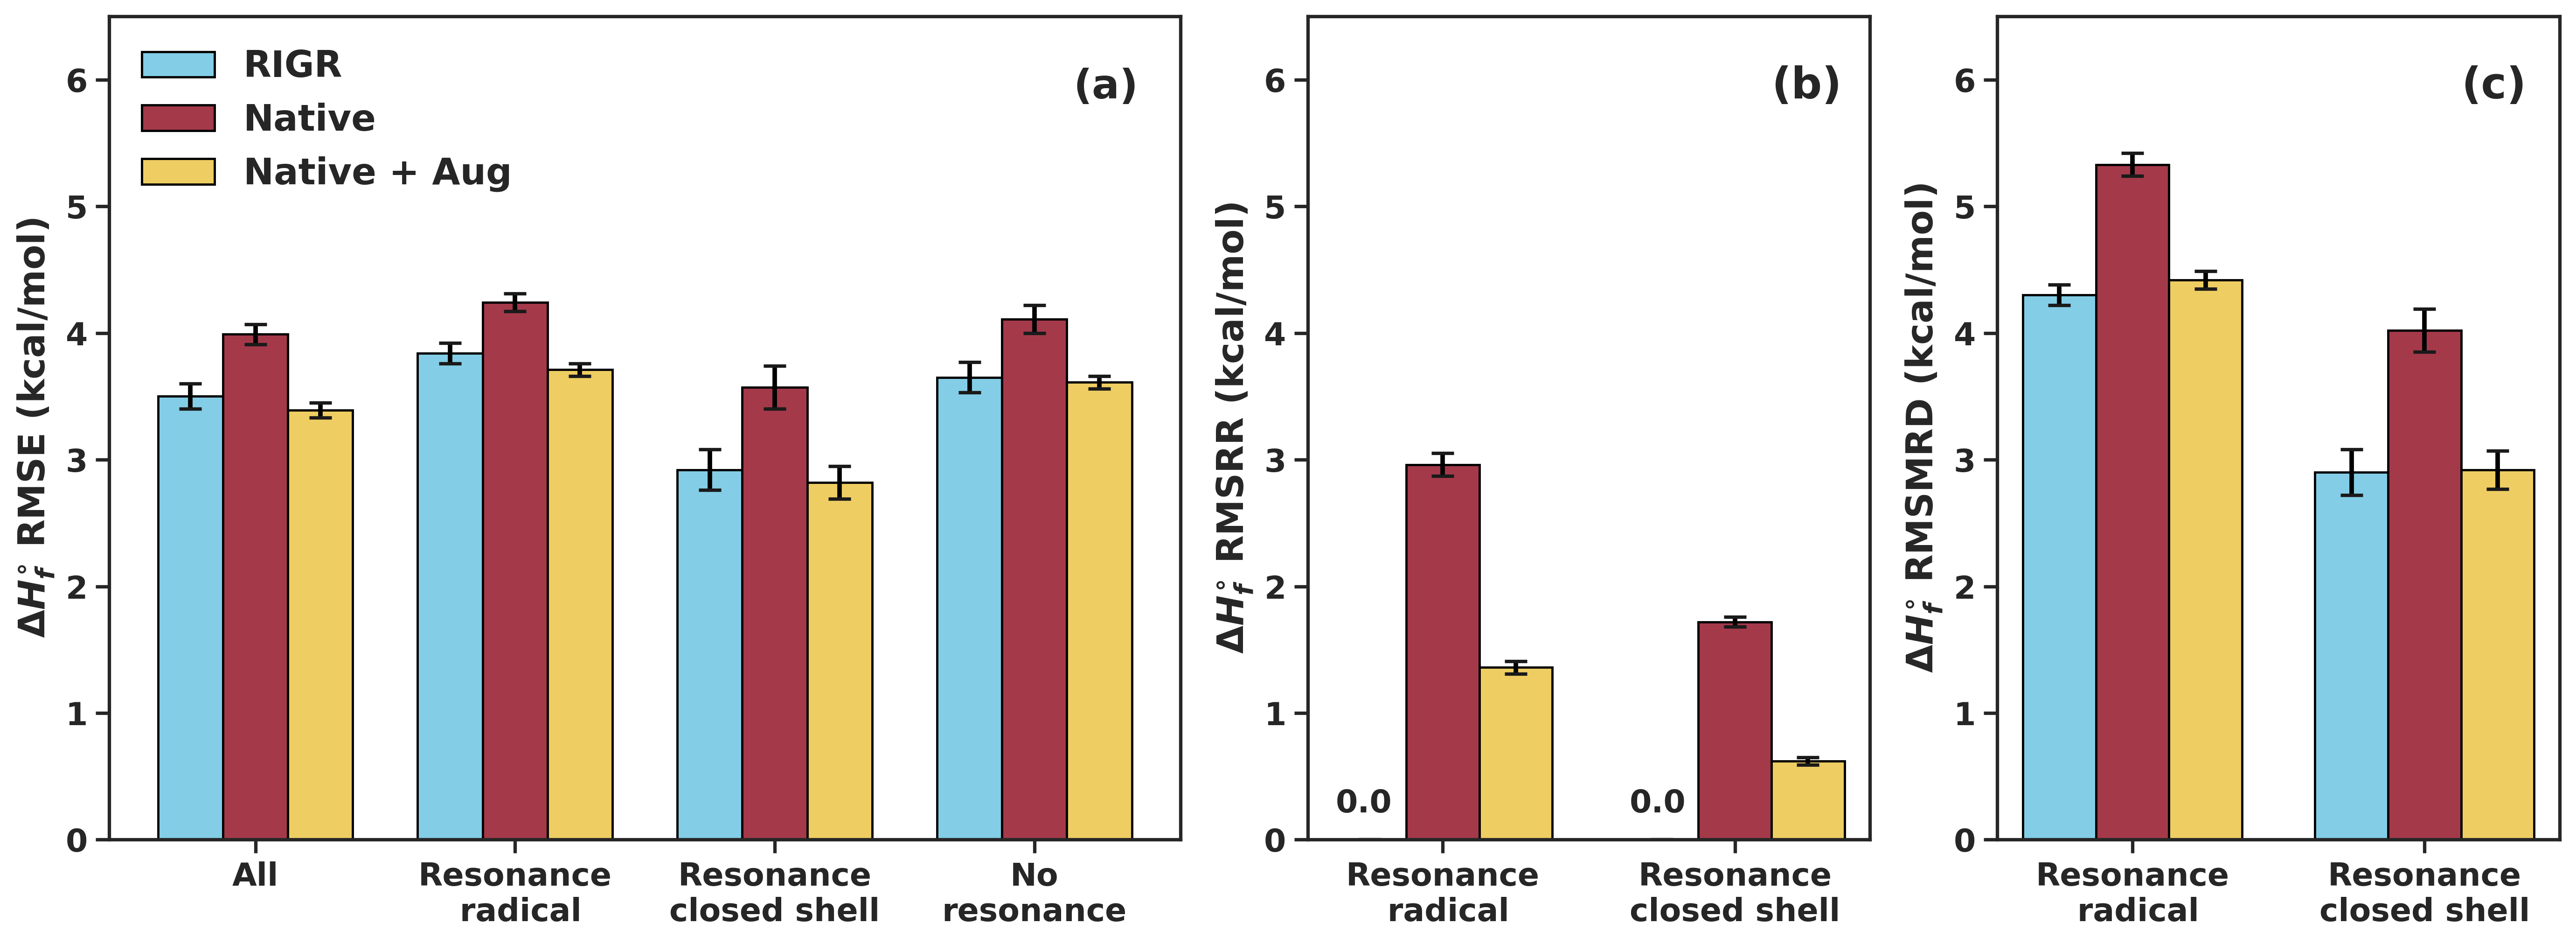

In [33]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 6), dpi=350)
gs = gridspec.GridSpec(1, 3, width_ratios=[2, 1.05, 1.05])  # Change the width ratios as needed

# Create subplots and assign them to the grid spec
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

xs = np.arange(4)
width = 0.75/2
spacing = 0.5 
xs_spaced = xs + np.arange(len(xs)) * spacing
xs_res = np.arange(2)
xs_res_spaced = xs_res + np.arange(len(xs_res)) * spacing

ax1.bar(
    xs_spaced,
    error_results["run2-bof"]["rmse"],
    yerr = error_results["run2-bof"]["rmse_err"],
    label="run2-bof",
    width=width,
    color=my_blue,
    edgecolor='black',
    ecolor='black',
    capsize= 5 ,
)
ax1.bar(
    xs_spaced + width,
    error_results["run2-baseline"]["rmse"],
    yerr = error_results["run2-baseline"]["rmse_err"],
    label = "run2-baseline",
    width = width,
    color= my_red,
    edgecolor='black',
    ecolor='black',
    capsize= 5 ,
)

ax1.bar(
    xs_spaced + 2*width,
    error_results["run4-baseline"]["rmse"],
    yerr = error_results["run4-baseline"]["rmse_err"],
    label = "run4-baseline",
    width = width,
    color= my_yellow,
    edgecolor='black',
    ecolor='black',
    capsize= 5 ,
)

ax1.set_xticks([0.75/2, 1.875, 3.375, 4.875], ["All", "Resonance\n radical", "Resonance\nclosed shell", "No\nresonance"])
ax1.set_ylabel(r"$\Delta H_{f}^{\circ}$ RMSE (kcal/mol)")
legend = ax1.legend(["RIGR", "Native", "Native + Aug"], loc = 'upper left', frameon=False, handlelength = 2)
ax1.set_ylim([0, 6.5])
ax1.set_yticks(np.arange(7))
ax1.text(0.9, 0.9, "(a)", transform=ax1.transAxes, fontsize=18)



ax2.bar(
    xs_res_spaced,
    error_results["run2-bof"]["rmsrr"],
    yerr = error_results["run2-bof"]["rmsrr_err"],
    label = "run2-bof",
    width = width,
    color=my_blue,
    edgecolor='black',
    ecolor='black',
    capsize= 5 ,
)
ax2.bar(
    xs_res_spaced + width,
    error_results["run2-baseline"]["rmsrr"],
    yerr = error_results["run2-baseline"]["rmsrr_err"],
    label = "run2-baseline",
    width = width,
    color=my_red,
    edgecolor='black',
    ecolor='black',
    capsize= 5 ,
)

ax2.bar(
    xs_res_spaced + 2*width,
    error_results["run4-baseline"]["rmsrr"],
    yerr = error_results["run4-baseline"]["rmsrr_err"],
    label = "run4-baseline",
    width = width,
    color=my_yellow,
    edgecolor='black',
    ecolor='black',
    capsize= 5 ,
)

ax2.set_xticks([0.375, 1.875], ["Resonance\n radical", "Resonance\nclosed shell"])
ax2.set_ylabel(r"$\Delta H_{f}^{\circ}$ RMSRR (kcal/mol)")
ax2.set_ylim([0, 6.5])
ax2.set_yticks(np.arange(7))
ax2.text(0.825, 0.9, "(b)", transform=ax2.transAxes, fontsize=19)
ax2.text(0.05, 0.033, "0.0", transform=ax2.transAxes, fontsize=14)
ax2.text(0.572, 0.033, "0.0", transform=ax2.transAxes, fontsize=14)
# legend = ax2.legend(["RIGR", "Native", "Native + Aug"], loc = 'upper left', frameon=False, handlelength = 2)

ax3.bar(
    xs_res_spaced,
    error_results["run2-bof"]["rmsmrd"],
    yerr = error_results["run2-bof"]["rmsmrd_err"],
    label = "run2-bof",
    width = width,
    color=my_blue,
    edgecolor='black',
    ecolor='black',
    capsize= 5 ,
)
ax3.bar(
    xs_res_spaced + width,
    error_results["run2-baseline"]["rmsmrd"],
    yerr = error_results["run2-baseline"]["rmsmrd_err"],
    label = "run2-baseline",
    width = width,
    color=my_red,
    edgecolor='black',
    ecolor='black',
    capsize= 5 ,
)
ax3.bar(
    xs_res_spaced + 2*width,
    error_results["run4-baseline"]["rmsmrd"],
    yerr = error_results["run4-baseline"]["rmsmrd_err"],
    label = "run4-baseline",
    width = width,
    color=my_yellow,
    edgecolor='black',
    ecolor='black',
    capsize= 5 ,
)

ax3.set_xticks([0.375, 1.875], ["Resonance\n radical", "Resonance\nclosed shell"])
ax3.set_ylabel(r"$\Delta H_{f}^{\circ}$ RMSMRD (kcal/mol)")
ax3.set_ylim([0, 6.5])
ax3.set_yticks(np.arange(7))
ax3.text(0.825, 0.9, "(c)", transform=ax3.transAxes, fontsize=19)
# fig.subplots_adjust(hspace=0.3)
# fig.set_size_inches(16, 6)
fig.tight_layout()

fig.savefig("/home/akshatz/bond_order_free/figures/aug_results.pdf", bbox_inches="tight")
# fig.savefig("/home/akshatz/bond_order_free/figures/f5.svg")

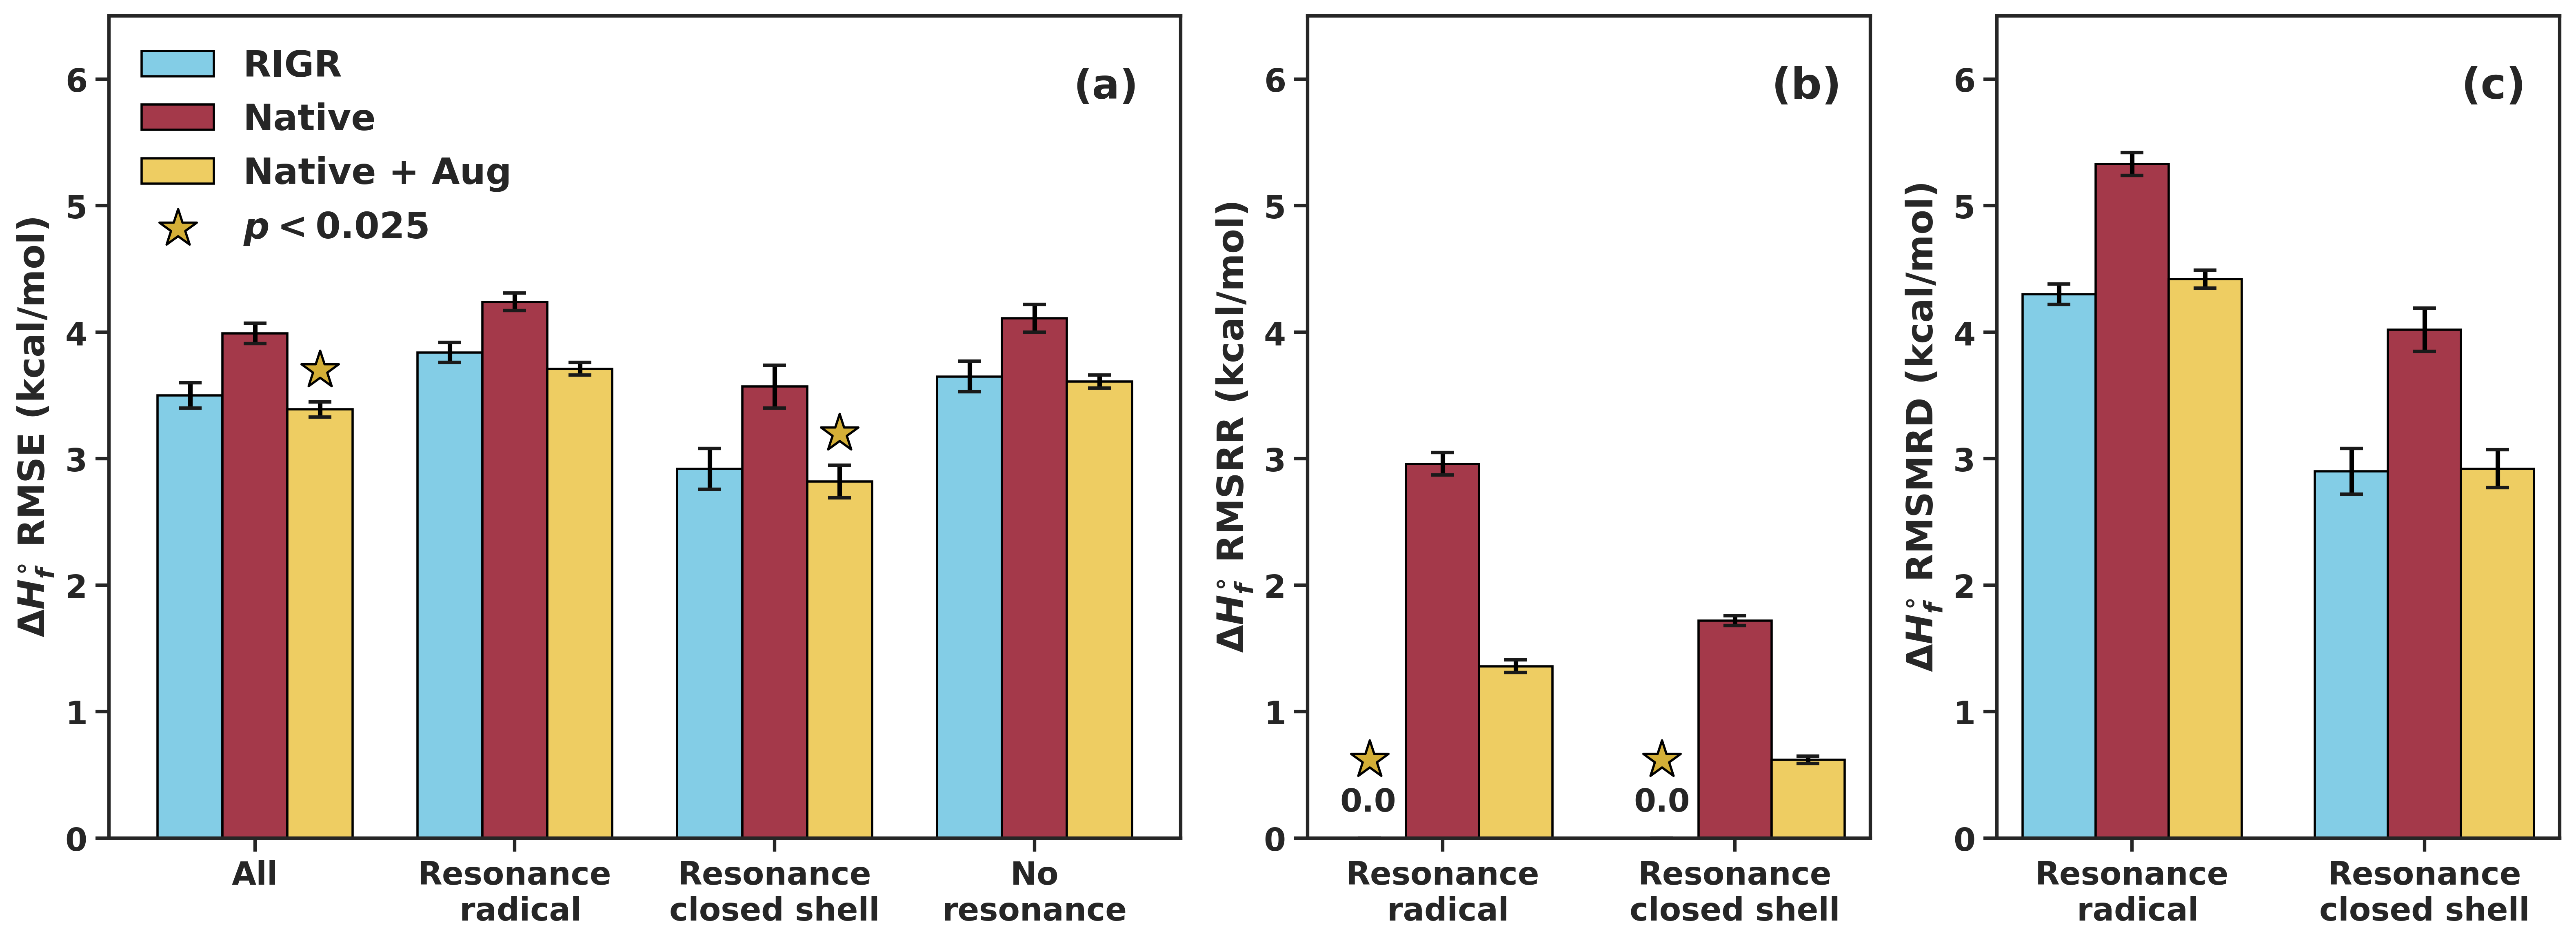

In [34]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 6), dpi=400)
gs = gridspec.GridSpec(1, 3, width_ratios=[2, 1.05, 1.05])  # Change the width ratios as needed

# Create subplots and assign them to the grid spec
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

xs = np.arange(4)
width = 0.75/2
spacing = 0.5 
xs_spaced = xs + np.arange(len(xs)) * spacing
xs_res = np.arange(2)
xs_res_spaced = xs_res + np.arange(len(xs_res)) * spacing

bof_bar = ax1.bar(
    xs_spaced,
    error_results["run2-bof"]["rmse"],
    yerr = error_results["run2-bof"]["rmse_err"],
    label="run2-bof",
    width=width,
    color=my_blue,
    edgecolor='black',
    ecolor='black',
    capsize= 5 ,
)
baseline_bar = ax1.bar(
    xs_spaced + width,
    error_results["run2-baseline"]["rmse"],
    yerr = error_results["run2-baseline"]["rmse_err"],
    label = "run2-baseline",
    width = width,
    color= my_red,
    edgecolor='black',
    ecolor='black',
    capsize= 5 ,
)

baseline_aug_bar = ax1.bar(
    xs_spaced + 2*width,
    error_results["run4-baseline"]["rmse"],
    yerr = error_results["run4-baseline"]["rmse_err"],
    label = "run4-baseline",
    width = width,
    color= my_yellow,
    edgecolor='black',
    ecolor='black',
    capsize= 5 ,
)

p_value_marker =  ax1.scatter(
    (xs_spaced+2*width)[[0,2]], 
    (np.array(error_results["run4-baseline"]["rmse"]) + np.array(error_results["run4-baseline"]["rmse_err"]) + 0.25)[[0,2]],
    marker='*', s=300, facecolor='#D4AF37', edgecolors='black', label="${p} < 0.025$"
)

ax1.set_xticks([0.75/2, 1.875, 3.375, 4.875], ["All", "Resonance\n radical", "Resonance\nclosed shell", "No\nresonance"])
ax1.set_ylabel(r"$\Delta H_{f}^{\circ}$ RMSE (kcal/mol)")
legend = ax1.legend(["RIGR", "Native", "Native + Aug"], loc = 'upper left', frameon=False, handlelength = 2)
legend = ax1.legend([bof_bar, baseline_bar, baseline_aug_bar, p_value_marker], ["RIGR", "Native", "Native + Aug","$p<0.025$"], loc='upper left', frameon=False, handlelength=2)
ax1.set_ylim([0, 6.5])
ax1.set_yticks(np.arange(7))
ax1.text(0.9, 0.9, "(a)", transform=ax1.transAxes, fontsize=18)


ax2.bar(
    xs_res_spaced,
    error_results["run2-bof"]["rmsrr"],
    yerr = error_results["run2-bof"]["rmsrr_err"],
    label = "run2-bof",
    width = width,
    color=my_blue,
    edgecolor='black',
    ecolor='black',
    capsize= 5 ,
)
ax2.bar(
    xs_res_spaced + width,
    error_results["run2-baseline"]["rmsrr"],
    yerr = error_results["run2-baseline"]["rmsrr_err"],
    label = "run2-baseline",
    width = width,
    color=my_red,
    edgecolor='black',
    ecolor='black',
    capsize= 5 ,
)

ax2.bar(
    xs_res_spaced + 2*width,
    error_results["run4-baseline"]["rmsrr"],
    yerr = error_results["run4-baseline"]["rmsrr_err"],
    label = "run4-baseline",
    width = width,
    color=my_yellow,
    edgecolor='black',
    ecolor='black',
    capsize= 5 ,
)

p_value_marker =  ax2.scatter(
    (xs_res_spaced)[[0,1]], 
    (np.array(error_results["run2-bof"]["rmsrr"]) + np.array(error_results["run2-bof"]["rmsrr_err"]) + 0.37 + 0.25)[[0,1]],
    marker='*', s=300, facecolor='#D4AF37', edgecolors='black', label="${p} < 0.025$"
)

ax2.set_xticks([0.375, 1.875], ["Resonance\n radical", "Resonance\nclosed shell"])
ax2.set_ylabel(r"$\Delta H_{f}^{\circ}$ RMSRR (kcal/mol)")
ax2.set_ylim([0, 6.5])
ax2.set_yticks(np.arange(7))
ax2.text(0.825, 0.9, "(b)", transform=ax2.transAxes, fontsize=19)
ax2.text(0.058, 0.033, "0.0", transform=ax2.transAxes, fontsize=14)
ax2.text(0.580, 0.033, "0.0", transform=ax2.transAxes, fontsize=14)
# legend = ax2.legend(["RIGR", "Native", "Native + Aug"], loc = 'upper left', frameon=False, handlelength = 2)

ax3.bar(
    xs_res_spaced,
    error_results["run2-bof"]["rmsmrd"],
    yerr = error_results["run2-bof"]["rmsmrd_err"],
    label = "run2-bof",
    width = width,
    color=my_blue,
    edgecolor='black',
    ecolor='black',
    capsize= 5 ,
)
ax3.bar(
    xs_res_spaced + width,
    error_results["run2-baseline"]["rmsmrd"],
    yerr = error_results["run2-baseline"]["rmsmrd_err"],
    label = "run2-baseline",
    width = width,
    color=my_red,
    edgecolor='black',
    ecolor='black',
    capsize= 5 ,
)
ax3.bar(
    xs_res_spaced + 2*width,
    error_results["run4-baseline"]["rmsmrd"],
    yerr = error_results["run4-baseline"]["rmsmrd_err"],
    label = "run4-baseline",
    width = width,
    color=my_yellow,
    edgecolor='black',
    ecolor='black',
    capsize= 5 ,
)

ax3.set_xticks([0.375, 1.875], ["Resonance\n radical", "Resonance\nclosed shell"])
ax3.set_ylabel(r"$\Delta H_{f}^{\circ}$ RMSMRD (kcal/mol)")
ax3.set_ylim([0, 6.5])
ax3.set_yticks(np.arange(7))
ax3.text(0.825, 0.9, "(c)", transform=ax3.transAxes, fontsize=19)
fig.tight_layout()

fig.savefig("/home/akshatz/bond_order_free/figures/aug_results_p.pdf", bbox_inches="tight")
# fig.savefig("/home/akshatz/bond_order_free/figures/f5.svg")

In [35]:
# fig, (ax2, ax3) = plt.subplots(1, 2, figsize=(8, 6))
# fig.subplots_adjust(wspace=0.5, hspace=0.5)
# xs = np.arange(4)
# width = 0.75/2
# spacing = 0.5 
# xs_spaced = xs + np.arange(len(xs)) * spacing
# xs_res = np.arange(2)
# xs_res_spaced = xs_res + np.arange(len(xs_res)) * spacing

# ax2.bar(
#     xs_res_spaced,
#     error_results["run2-bof"]["rmsrr"],
#     yerr = error_results["run2-bof"]["rmsrr_err"],
#     label = "run2-bof",
#     width = width,
#     color=my_blue,
#     edgecolor='black',
#     ecolor='black',
#     capsize= 5 ,
# )
# ax2.bar(
#     xs_res_spaced + width,
#     error_results["run2-baseline"]["rmsrr"],
#     yerr = error_results["run2-baseline"]["rmsrr_err"],
#     label = "run2-baseline",
#     width = width,
#     color=my_red,
#     edgecolor='black',
#     ecolor='black',
#     capsize= 5 ,
# )

# ax2.bar(
#     xs_res_spaced + 2*width,
#     error_results["run4-baseline"]["rmsrr"],
#     yerr = error_results["run4-baseline"]["rmsrr_err"],
#     label = "run4-baseline",
#     width = width,
#     color=my_yellow,
#     edgecolor='black',
#     ecolor='black',
#     capsize= 5 ,
# )

# ax2.set_xticks([0.375, 1.875], ["Resonance\n radical", "Resonance\nclosed shell"])
# ax2.set_ylabel(r"$\Delta H_{f}^{\circ}$ RMSRR (kcal/mol)")
# ax2.set_ylim([0, 6.5])
# ax2.set_yticks(np.arange(7))
# # legend = ax2.legend(["RIGR", "Native", "Native + Aug"], loc = 'upper left', frameon=False, handlelength = 2)

# ax3.bar(
#     xs_res_spaced,
#     error_results["run2-bof"]["rmsmrd"],
#     yerr = error_results["run2-bof"]["rmsmrd_err"],
#     label = "run2-bof",
#     width = width,
#     color=my_blue,
#     edgecolor='black',
#     ecolor='black',
#     capsize= 5 ,
# )
# ax3.bar(
#     xs_res_spaced + width,
#     error_results["run2-baseline"]["rmsmrd"],
#     yerr = error_results["run2-baseline"]["rmsmrd_err"],
#     label = "run2-baseline",
#     width = width,
#     color=my_red,
#     edgecolor='black',
#     ecolor='black',
#     capsize= 5 ,
# )
# ax3.bar(
#     xs_res_spaced + 2*width,
#     error_results["run4-baseline"]["rmsmrd"],
#     yerr = error_results["run4-baseline"]["rmsmrd_err"],
#     label = "run4-baseline",
#     width = width,
#     color=my_yellow,
#     edgecolor='black',
#     ecolor='black',
#     capsize= 5 ,
# )

# ax3.set_xticks([0.375, 1.875], ["Resonance\n radical", "Resonance\nclosed shell"])
# ax3.set_ylabel(r"$\Delta H_{f}^{\circ}$ RMSMRD (kcal/mol)")
# ax3.set_ylim([0, 6.5])
# ax3.set_yticks(np.arange(7))
# # fig.subplots_adjust(hspace=0.3)
# fig.set_size_inches(8, 6)
# fig.tight_layout()
# # fig.savefig("/home/akshatz/bond_order_free/figures/f5b.pdf", bbox_inches="tight")

## Downsampling

### chemprop downsampling

In [36]:
downsample_folder_names = ["50k", "20k", "10k", "5k", "2k", "1k", "500", "200"]

for size in downsample_folder_names:
    if size == "50k":
        df = pd.read_csv(f'run1_baseline_best/results_aug/test_preds_0.csv')
        df = df.merge(all_aug_data_set[["resonance_smis", "parent_smi", "subset"]], how="left", on="resonance_smis")
        y_true = df["H298_kcal"].values
        y_pred = df["pred_0"].values

        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        mae_res_rad = mean_absolute_error(df.loc[df['subset'] == 'res_radical', 'H298_kcal'], 
                                        df.loc[df['subset'] == 'res_radical', 'pred_0'])
        rmse_res_rad = np.sqrt(mean_squared_error(df.loc[df['subset'] == 'res_radical', 'H298_kcal'], 
                                        df.loc[df['subset'] == 'res_radical', 'pred_0']))

        mae_res_cs = mean_absolute_error(df.loc[df['subset'] == 'res_closed_shell', 'H298_kcal'], 
                                        df.loc[df['subset'] == 'res_closed_shell', 'pred_0'])
        rmse_res_cs = np.sqrt(mean_squared_error(df.loc[df['subset'] == 'res_closed_shell', 'H298_kcal'], 
                                        df.loc[df['subset'] == 'res_closed_shell', 'pred_0']))

        mae_non_res = mean_absolute_error(df.loc[df['subset'] == 'non_resonance', 'H298_kcal'], 
                                        df.loc[df['subset'] == 'non_resonance', 'pred_0'])
        rmse_non_res = np.sqrt(mean_squared_error(df.loc[df['subset'] == 'non_resonance', 'H298_kcal'], 
                                        df.loc[df['subset'] == 'non_resonance', 'pred_0']))

        rmsrr_res_rad = compute_rmsrr(df.query('subset == "res_radical"'), 'pred_0','parent_smi')
        rmsrr_res_cs = compute_rmsrr(df.query('subset == "res_closed_shell"'), 'pred_0','parent_smi')

        rmsmrd_res_rad = compute_rmsmrd(df.query('subset == "res_radical"'), 'parent_smi', 'pred_0', 'H298_kcal')
        rmsmrd_res_cs = compute_rmsmrd(df.query('subset == "res_closed_shell"'), 'parent_smi', 'pred_0', 'H298_kcal')

        error_results[f'{size}-run1-baseline-best-aug'] = dict()
        error_results[f'{size}-run1-baseline-best-aug']["mae"] = [mae, mae_res_rad, mae_res_cs, mae_non_res]
        error_results[f'{size}-run1-baseline-best-aug']["rmse"] = [rmse, rmse_res_rad, rmse_res_cs, rmse_non_res]
        error_results[f'{size}-run1-baseline-best-aug']["rmsrr"] = [rmsrr_res_rad, rmsrr_res_cs]
        error_results[f'{size}-run1-baseline-best-aug']["rmsmrd"] = [rmsmrd_res_rad, rmsmrd_res_cs]
    
    else:
        df = pd.read_csv(f'../rigr_h298_{size}/run1_baseline_best/results_aug/test_preds.csv')
        df = df.merge(all_aug_data_set[["resonance_smis", "parent_smi", "subset"]], how="left", on="resonance_smis")
        y_true = df["H298_kcal"].values
        y_pred = df["pred_0"].values

        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        mae_res_rad = mean_absolute_error(df.loc[df['subset'] == 'res_radical', 'H298_kcal'], 
                                        df.loc[df['subset'] == 'res_radical', 'pred_0'])
        rmse_res_rad = np.sqrt(mean_squared_error(df.loc[df['subset'] == 'res_radical', 'H298_kcal'], 
                                        df.loc[df['subset'] == 'res_radical', 'pred_0']))

        mae_res_cs = mean_absolute_error(df.loc[df['subset'] == 'res_closed_shell', 'H298_kcal'], 
                                        df.loc[df['subset'] == 'res_closed_shell', 'pred_0'])
        rmse_res_cs = np.sqrt(mean_squared_error(df.loc[df['subset'] == 'res_closed_shell', 'H298_kcal'], 
                                        df.loc[df['subset'] == 'res_closed_shell', 'pred_0']))

        mae_non_res = mean_absolute_error(df.loc[df['subset'] == 'non_resonance', 'H298_kcal'], 
                                        df.loc[df['subset'] == 'non_resonance', 'pred_0'])
        rmse_non_res = np.sqrt(mean_squared_error(df.loc[df['subset'] == 'non_resonance', 'H298_kcal'], 
                                        df.loc[df['subset'] == 'non_resonance', 'pred_0']))
        
        rmsrr_res_rad = compute_rmsrr(df.query('subset == "res_radical"'), 'pred_0','parent_smi')
        rmsrr_res_cs = compute_rmsrr(df.query('subset == "res_closed_shell"'), 'pred_0','parent_smi')

        rmsmrd_res_rad = compute_rmsmrd(df.query('subset == "res_radical"'), 'parent_smi', 'pred_0', 'H298_kcal')
        rmsmrd_res_cs = compute_rmsmrd(df.query('subset == "res_closed_shell"'), 'parent_smi', 'pred_0', 'H298_kcal')
        
        error_results[f'{size}-run1-baseline-best-aug'] = dict()
        error_results[f'{size}-run1-baseline-best-aug']["mae"] = [mae, mae_res_rad, mae_res_cs, mae_non_res]
        error_results[f'{size}-run1-baseline-best-aug']["rmse"] = [rmse, rmse_res_rad, rmse_res_cs, rmse_non_res]
        error_results[f'{size}-run1-baseline-best-aug']["rmsrr"] = [rmsrr_res_rad, rmsrr_res_cs]
        error_results[f'{size}-run1-baseline-best-aug']["rmsmrd"] = [rmsmrd_res_rad, rmsmrd_res_cs]

downsample_folder_names = ["50k", "20k", "10k", "5k", "2k", "1k", "500", "200"]

downsample_mae_run1_baseline_aug = []
downsample_rmse_run1_baseline_aug = []
for size in downsample_folder_names:
    downsample_mae_run1_baseline_aug.append(error_results[f'{size}-run1-baseline-best-aug']["mae"][0])
    downsample_rmse_run1_baseline_aug.append(error_results[f'{size}-run1-baseline-best-aug']["rmse"][0])

downsample_mae_run1_baseline_aug_res_rad = []
downsample_rmse_run1_baseline_aug_res_rad = []
downsample_rmsrr_run1_baseline_aug_res_rad = []
downsample_rmsmrd_run1_baseline_aug_res_rad = []

for size in downsample_folder_names:
    downsample_mae_run1_baseline_aug_res_rad.append(error_results[f'{size}-run1-baseline-best-aug']["mae"][1])
    downsample_rmse_run1_baseline_aug_res_rad.append(error_results[f'{size}-run1-baseline-best-aug']["rmse"][1])
    downsample_rmsrr_run1_baseline_aug_res_rad.append(error_results[f'{size}-run1-baseline-best-aug']["rmsrr"][0])
    downsample_rmsmrd_run1_baseline_aug_res_rad.append(error_results[f'{size}-run1-baseline-best-aug']["rmsmrd"][0])

downsample_mae_run1_baseline_aug_res_cs = []
downsample_rmse_run1_baseline_aug_res_cs = []
downsample_rmsrr_run1_baseline_aug_res_cs = []
downsample_rmsmrd_run1_baseline_aug_res_cs = []

for size in downsample_folder_names:
    downsample_mae_run1_baseline_aug_res_cs.append(error_results[f'{size}-run1-baseline-best-aug']["mae"][2])
    downsample_rmse_run1_baseline_aug_res_cs.append(error_results[f'{size}-run1-baseline-best-aug']["rmse"][2])
    downsample_rmsrr_run1_baseline_aug_res_cs.append(error_results[f'{size}-run1-baseline-best-aug']["rmsrr"][1])
    downsample_rmsmrd_run1_baseline_aug_res_cs.append(error_results[f'{size}-run1-baseline-best-aug']["rmsmrd"][1])

downsample_mae_run1_baseline_aug_non_res = []
downsample_rmse_run1_baseline_aug_non_res = []
for size in downsample_folder_names:
    downsample_mae_run1_baseline_aug_non_res.append(error_results[f'{size}-run1-baseline-best-aug']["mae"][3])
    downsample_rmse_run1_baseline_aug_non_res.append(error_results[f'{size}-run1-baseline-best-aug']["rmse"][3])


### rigr downsampling

In [37]:
downsample_folder_names = ["50k", "20k", "10k", "5k", "2k", "1k", "500", "200"]

for size in downsample_folder_names:
    if size == "50k":
        df = pd.read_csv(f'run1_bof_best/results_aug/test_preds_0.csv')
        df = df.merge(all_aug_data_set[["resonance_smis", "parent_smi", "subset"]], how="left", on="resonance_smis")
        y_true = df["H298_kcal"].values
        y_pred = df["pred_0"].values

        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        mae_res_rad = mean_absolute_error(df.loc[df['subset'] == 'res_radical', 'H298_kcal'], 
                                        df.loc[df['subset'] == 'res_radical', 'pred_0'])
        rmse_res_rad = np.sqrt(mean_squared_error(df.loc[df['subset'] == 'res_radical', 'H298_kcal'], 
                                        df.loc[df['subset'] == 'res_radical', 'pred_0']))

        mae_res_cs = mean_absolute_error(df.loc[df['subset'] == 'res_closed_shell', 'H298_kcal'], 
                                        df.loc[df['subset'] == 'res_closed_shell', 'pred_0'])
        rmse_res_cs = np.sqrt(mean_squared_error(df.loc[df['subset'] == 'res_closed_shell', 'H298_kcal'], 
                                        df.loc[df['subset'] == 'res_closed_shell', 'pred_0']))

        mae_non_res = mean_absolute_error(df.loc[df['subset'] == 'non_resonance', 'H298_kcal'], 
                                        df.loc[df['subset'] == 'non_resonance', 'pred_0'])
        rmse_non_res = np.sqrt(mean_squared_error(df.loc[df['subset'] == 'non_resonance', 'H298_kcal'], 
                                        df.loc[df['subset'] == 'non_resonance', 'pred_0']))

        rmsrr_res_rad = compute_rmsrr(df.query('subset == "res_radical"'), 'pred_0','parent_smi')
        rmsrr_res_cs = compute_rmsrr(df.query('subset == "res_closed_shell"'), 'pred_0','parent_smi')

        rmsmrd_res_rad = compute_rmsmrd(df.query('subset == "res_radical"'), 'parent_smi', 'pred_0', 'H298_kcal')
        rmsmrd_res_cs = compute_rmsmrd(df.query('subset == "res_closed_shell"'), 'parent_smi', 'pred_0', 'H298_kcal')

        error_results[f'{size}-run1-bof-best-aug'] = dict()
        error_results[f'{size}-run1-bof-best-aug']["mae"] = [mae, mae_res_rad, mae_res_cs, mae_non_res]
        error_results[f'{size}-run1-bof-best-aug']["rmse"] = [rmse, rmse_res_rad, rmse_res_cs, rmse_non_res]
        error_results[f'{size}-run1-bof-best-aug']["rmsrr"] = [rmsrr_res_rad, rmsrr_res_cs]
        error_results[f'{size}-run1-bof-best-aug']["rmsmrd"] = [rmsmrd_res_rad, rmsmrd_res_cs]
    
    else:
        df = pd.read_csv(f'../rigr_h298_{size}/run1_bof_best/results_aug/test_preds.csv')
        df = df.merge(all_aug_data_set[["resonance_smis", "parent_smi", "subset"]], how="left", on="resonance_smis")
        y_true = df["H298_kcal"].values
        y_pred = df["pred_0"].values

        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        mae_res_rad = mean_absolute_error(df.loc[df['subset'] == 'res_radical', 'H298_kcal'], 
                                        df.loc[df['subset'] == 'res_radical', 'pred_0'])
        rmse_res_rad = np.sqrt(mean_squared_error(df.loc[df['subset'] == 'res_radical', 'H298_kcal'], 
                                        df.loc[df['subset'] == 'res_radical', 'pred_0']))

        mae_res_cs = mean_absolute_error(df.loc[df['subset'] == 'res_closed_shell', 'H298_kcal'], 
                                        df.loc[df['subset'] == 'res_closed_shell', 'pred_0'])
        rmse_res_cs = np.sqrt(mean_squared_error(df.loc[df['subset'] == 'res_closed_shell', 'H298_kcal'], 
                                        df.loc[df['subset'] == 'res_closed_shell', 'pred_0']))

        mae_non_res = mean_absolute_error(df.loc[df['subset'] == 'non_resonance', 'H298_kcal'], 
                                        df.loc[df['subset'] == 'non_resonance', 'pred_0'])
        rmse_non_res = np.sqrt(mean_squared_error(df.loc[df['subset'] == 'non_resonance', 'H298_kcal'], 
                                        df.loc[df['subset'] == 'non_resonance', 'pred_0']))
        
        rmsrr_res_rad = compute_rmsrr(df.query('subset == "res_radical"'), 'pred_0','parent_smi')
        rmsrr_res_cs = compute_rmsrr(df.query('subset == "res_closed_shell"'), 'pred_0','parent_smi')

        rmsmrd_res_rad = compute_rmsmrd(df.query('subset == "res_radical"'), 'parent_smi', 'pred_0', 'H298_kcal')
        rmsmrd_res_cs = compute_rmsmrd(df.query('subset == "res_closed_shell"'), 'parent_smi', 'pred_0', 'H298_kcal')
        
        error_results[f'{size}-run1-bof-best-aug'] = dict()
        error_results[f'{size}-run1-bof-best-aug']["mae"] = [mae, mae_res_rad, mae_res_cs, mae_non_res]
        error_results[f'{size}-run1-bof-best-aug']["rmse"] = [rmse, rmse_res_rad, rmse_res_cs, rmse_non_res]
        error_results[f'{size}-run1-bof-best-aug']["rmsrr"] = [rmsrr_res_rad, rmsrr_res_cs]
        error_results[f'{size}-run1-bof-best-aug']["rmsmrd"] = [rmsmrd_res_rad, rmsmrd_res_cs]

downsample_folder_names = ["50k", "20k", "10k", "5k", "2k", "1k", "500", "200"]

downsample_mae_run1_bof_aug = []
downsample_rmse_run1_bof_aug = []
for size in downsample_folder_names:
    downsample_mae_run1_bof_aug.append(error_results[f'{size}-run1-bof-best-aug']["mae"][0])
    downsample_rmse_run1_bof_aug.append(error_results[f'{size}-run1-bof-best-aug']["rmse"][0])

downsample_mae_run1_bof_aug_res_rad = []
downsample_rmse_run1_bof_aug_res_rad = []
downsample_rmsrr_run1_bof_aug_res_rad = []
downsample_rmsmrd_run1_bof_aug_res_rad = []

for size in downsample_folder_names:
    downsample_mae_run1_bof_aug_res_rad.append(error_results[f'{size}-run1-bof-best-aug']["mae"][1])
    downsample_rmse_run1_bof_aug_res_rad.append(error_results[f'{size}-run1-bof-best-aug']["rmse"][1])
    downsample_rmsrr_run1_bof_aug_res_rad.append(error_results[f'{size}-run1-bof-best-aug']["rmsrr"][0])
    downsample_rmsmrd_run1_bof_aug_res_rad.append(error_results[f'{size}-run1-bof-best-aug']["rmsmrd"][0])

downsample_mae_run1_bof_aug_res_cs = []
downsample_rmse_run1_bof_aug_res_cs = []
downsample_rmsrr_run1_bof_aug_res_cs = []
downsample_rmsmrd_run1_bof_aug_res_cs = []

for size in downsample_folder_names:
    downsample_mae_run1_bof_aug_res_cs.append(error_results[f'{size}-run1-bof-best-aug']["mae"][2])
    downsample_rmse_run1_bof_aug_res_cs.append(error_results[f'{size}-run1-bof-best-aug']["rmse"][2])
    downsample_rmsrr_run1_bof_aug_res_cs.append(error_results[f'{size}-run1-bof-best-aug']["rmsrr"][1])
    downsample_rmsmrd_run1_bof_aug_res_cs.append(error_results[f'{size}-run1-bof-best-aug']["rmsmrd"][1])

downsample_mae_run1_bof_aug_non_res = []
downsample_rmse_run1_bof_aug_non_res = []
for size in downsample_folder_names:
    downsample_mae_run1_bof_aug_non_res.append(error_results[f'{size}-run1-bof-best-aug']["mae"][3])
    downsample_rmse_run1_bof_aug_non_res.append(error_results[f'{size}-run1-bof-best-aug']["rmse"][3])

### chemprop-aug downsampling

In [38]:
downsample_folder_names = ["50k", "20k", "10k", "5k", "2k", "1k", "500", "200"]

for size in downsample_folder_names:
    if size == "50k":
        df = pd.read_csv(f'run4_baseline_best/results_aug/test_preds_0.csv')
        df = df.merge(all_aug_data_set[["resonance_smis", "parent_smi", "subset"]], how="left", on="resonance_smis")
        y_true = df["H298_kcal"].values
        y_pred = df["pred_0"].values

        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        mae_res_rad = mean_absolute_error(df.loc[df['subset'] == 'res_radical', 'H298_kcal'], 
                                        df.loc[df['subset'] == 'res_radical', 'pred_0'])
        rmse_res_rad = np.sqrt(mean_squared_error(df.loc[df['subset'] == 'res_radical', 'H298_kcal'], 
                                        df.loc[df['subset'] == 'res_radical', 'pred_0']))

        mae_res_cs = mean_absolute_error(df.loc[df['subset'] == 'res_closed_shell', 'H298_kcal'], 
                                        df.loc[df['subset'] == 'res_closed_shell', 'pred_0'])
        rmse_res_cs = np.sqrt(mean_squared_error(df.loc[df['subset'] == 'res_closed_shell', 'H298_kcal'], 
                                        df.loc[df['subset'] == 'res_closed_shell', 'pred_0']))

        mae_non_res = mean_absolute_error(df.loc[df['subset'] == 'non_resonance', 'H298_kcal'], 
                                        df.loc[df['subset'] == 'non_resonance', 'pred_0'])
        rmse_non_res = np.sqrt(mean_squared_error(df.loc[df['subset'] == 'non_resonance', 'H298_kcal'], 
                                        df.loc[df['subset'] == 'non_resonance', 'pred_0']))

        rmsrr_res_rad = compute_rmsrr(df.query('subset == "res_radical"'), 'pred_0','parent_smi')
        rmsrr_res_cs = compute_rmsrr(df.query('subset == "res_closed_shell"'), 'pred_0','parent_smi')

        rmsmrd_res_rad = compute_rmsmrd(df.query('subset == "res_radical"'), 'parent_smi', 'pred_0', 'H298_kcal')
        rmsmrd_res_cs = compute_rmsmrd(df.query('subset == "res_closed_shell"'), 'parent_smi', 'pred_0', 'H298_kcal')

        error_results[f'{size}-run4-baseline-best-aug'] = dict()
        error_results[f'{size}-run4-baseline-best-aug']["mae"] = [mae, mae_res_rad, mae_res_cs, mae_non_res]
        error_results[f'{size}-run4-baseline-best-aug']["rmse"] = [rmse, rmse_res_rad, rmse_res_cs, rmse_non_res]
        error_results[f'{size}-run4-baseline-best-aug']["rmsrr"] = [rmsrr_res_rad, rmsrr_res_cs]
        error_results[f'{size}-run4-baseline-best-aug']["rmsmrd"] = [rmsmrd_res_rad, rmsmrd_res_cs]
    
    else:
        df = pd.read_csv(f'../rigr_h298_{size}/run4_baseline_best/results_aug/test_preds.csv')
        df = df.merge(all_aug_data_set[["resonance_smis", "parent_smi","subset"]], how="left", on="resonance_smis")
        y_true = df["H298_kcal"].values
        y_pred = df["pred_0"].values

        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        mae_res_rad = mean_absolute_error(df.loc[df['subset'] == 'res_radical', 'H298_kcal'], 
                                        df.loc[df['subset'] == 'res_radical', 'pred_0'])
        rmse_res_rad = np.sqrt(mean_squared_error(df.loc[df['subset'] == 'res_radical', 'H298_kcal'], 
                                        df.loc[df['subset'] == 'res_radical', 'pred_0']))

        mae_res_cs = mean_absolute_error(df.loc[df['subset'] == 'res_closed_shell', 'H298_kcal'], 
                                        df.loc[df['subset'] == 'res_closed_shell', 'pred_0'])
        rmse_res_cs = np.sqrt(mean_squared_error(df.loc[df['subset'] == 'res_closed_shell', 'H298_kcal'], 
                                        df.loc[df['subset'] == 'res_closed_shell', 'pred_0']))

        mae_non_res = mean_absolute_error(df.loc[df['subset'] == 'non_resonance', 'H298_kcal'], 
                                        df.loc[df['subset'] == 'non_resonance', 'pred_0'])
        rmse_non_res = np.sqrt(mean_squared_error(df.loc[df['subset'] == 'non_resonance', 'H298_kcal'], 
                                        df.loc[df['subset'] == 'non_resonance', 'pred_0']))
        
        rmsrr_res_rad = compute_rmsrr(df.query('subset == "res_radical"'), 'pred_0','parent_smi')
        rmsrr_res_cs = compute_rmsrr(df.query('subset == "res_closed_shell"'), 'pred_0','parent_smi')

        rmsmrd_res_rad = compute_rmsmrd(df.query('subset == "res_radical"'), 'parent_smi', 'pred_0', 'H298_kcal')
        rmsmrd_res_cs = compute_rmsmrd(df.query('subset == "res_closed_shell"'), 'parent_smi', 'pred_0', 'H298_kcal')
        
        error_results[f'{size}-run4-baseline-best-aug'] = dict()
        error_results[f'{size}-run4-baseline-best-aug']["mae"] = [mae, mae_res_rad, mae_res_cs, mae_non_res]
        error_results[f'{size}-run4-baseline-best-aug']["rmse"] = [rmse, rmse_res_rad, rmse_res_cs, rmse_non_res]
        error_results[f'{size}-run4-baseline-best-aug']["rmsrr"] = [rmsrr_res_rad, rmsrr_res_cs]
        error_results[f'{size}-run4-baseline-best-aug']["rmsmrd"] = [rmsmrd_res_rad, rmsmrd_res_cs]

downsample_folder_names = ["50k", "20k", "10k", "5k", "2k", "1k", "500", "200"]

downsample_mae_run4_baseline_aug = []
downsample_rmse_run4_baseline_aug = []
for size in downsample_folder_names:
    downsample_mae_run4_baseline_aug.append(error_results[f'{size}-run4-baseline-best-aug']["mae"][0])
    downsample_rmse_run4_baseline_aug.append(error_results[f'{size}-run4-baseline-best-aug']["rmse"][0])

downsample_mae_run4_baseline_aug_res_rad = []
downsample_rmse_run4_baseline_aug_res_rad = []
downsample_rmsrr_run4_baseline_aug_res_rad = []
downsample_rmsmrd_run4_baseline_aug_res_rad = []

for size in downsample_folder_names:
    downsample_mae_run4_baseline_aug_res_rad.append(error_results[f'{size}-run4-baseline-best-aug']["mae"][1])
    downsample_rmse_run4_baseline_aug_res_rad.append(error_results[f'{size}-run4-baseline-best-aug']["rmse"][1])
    downsample_rmsrr_run4_baseline_aug_res_rad.append(error_results[f'{size}-run4-baseline-best-aug']["rmsrr"][0])
    downsample_rmsmrd_run4_baseline_aug_res_rad.append(error_results[f'{size}-run4-baseline-best-aug']["rmsmrd"][0])

downsample_mae_run4_baseline_aug_res_cs = []
downsample_rmse_run4_baseline_aug_res_cs = []
downsample_rmsrr_run4_baseline_aug_res_cs = []
downsample_rmsmrd_run4_baseline_aug_res_cs = []

for size in downsample_folder_names:
    downsample_mae_run4_baseline_aug_res_cs.append(error_results[f'{size}-run4-baseline-best-aug']["mae"][2])
    downsample_rmse_run4_baseline_aug_res_cs.append(error_results[f'{size}-run4-baseline-best-aug']["rmse"][2])
    downsample_rmsrr_run4_baseline_aug_res_cs.append(error_results[f'{size}-run4-baseline-best-aug']["rmsrr"][1])
    downsample_rmsmrd_run4_baseline_aug_res_cs.append(error_results[f'{size}-run4-baseline-best-aug']["rmsmrd"][1])

downsample_mae_run4_baseline_aug_non_res = []
downsample_rmse_run4_baseline_aug_non_res = []
for size in downsample_folder_names:
    downsample_mae_run4_baseline_aug_non_res.append(error_results[f'{size}-run4-baseline-best-aug']["mae"][3])
    downsample_rmse_run4_baseline_aug_non_res.append(error_results[f'{size}-run4-baseline-best-aug']["rmse"][3])


## Figure 3

In [39]:
x_values = [40000, 20000, 10000, 5000, 2000, 1000, 500, 200]

/tmp/ipykernel_670298/3722806.py:30: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax1.set_xlim([0, 50000])


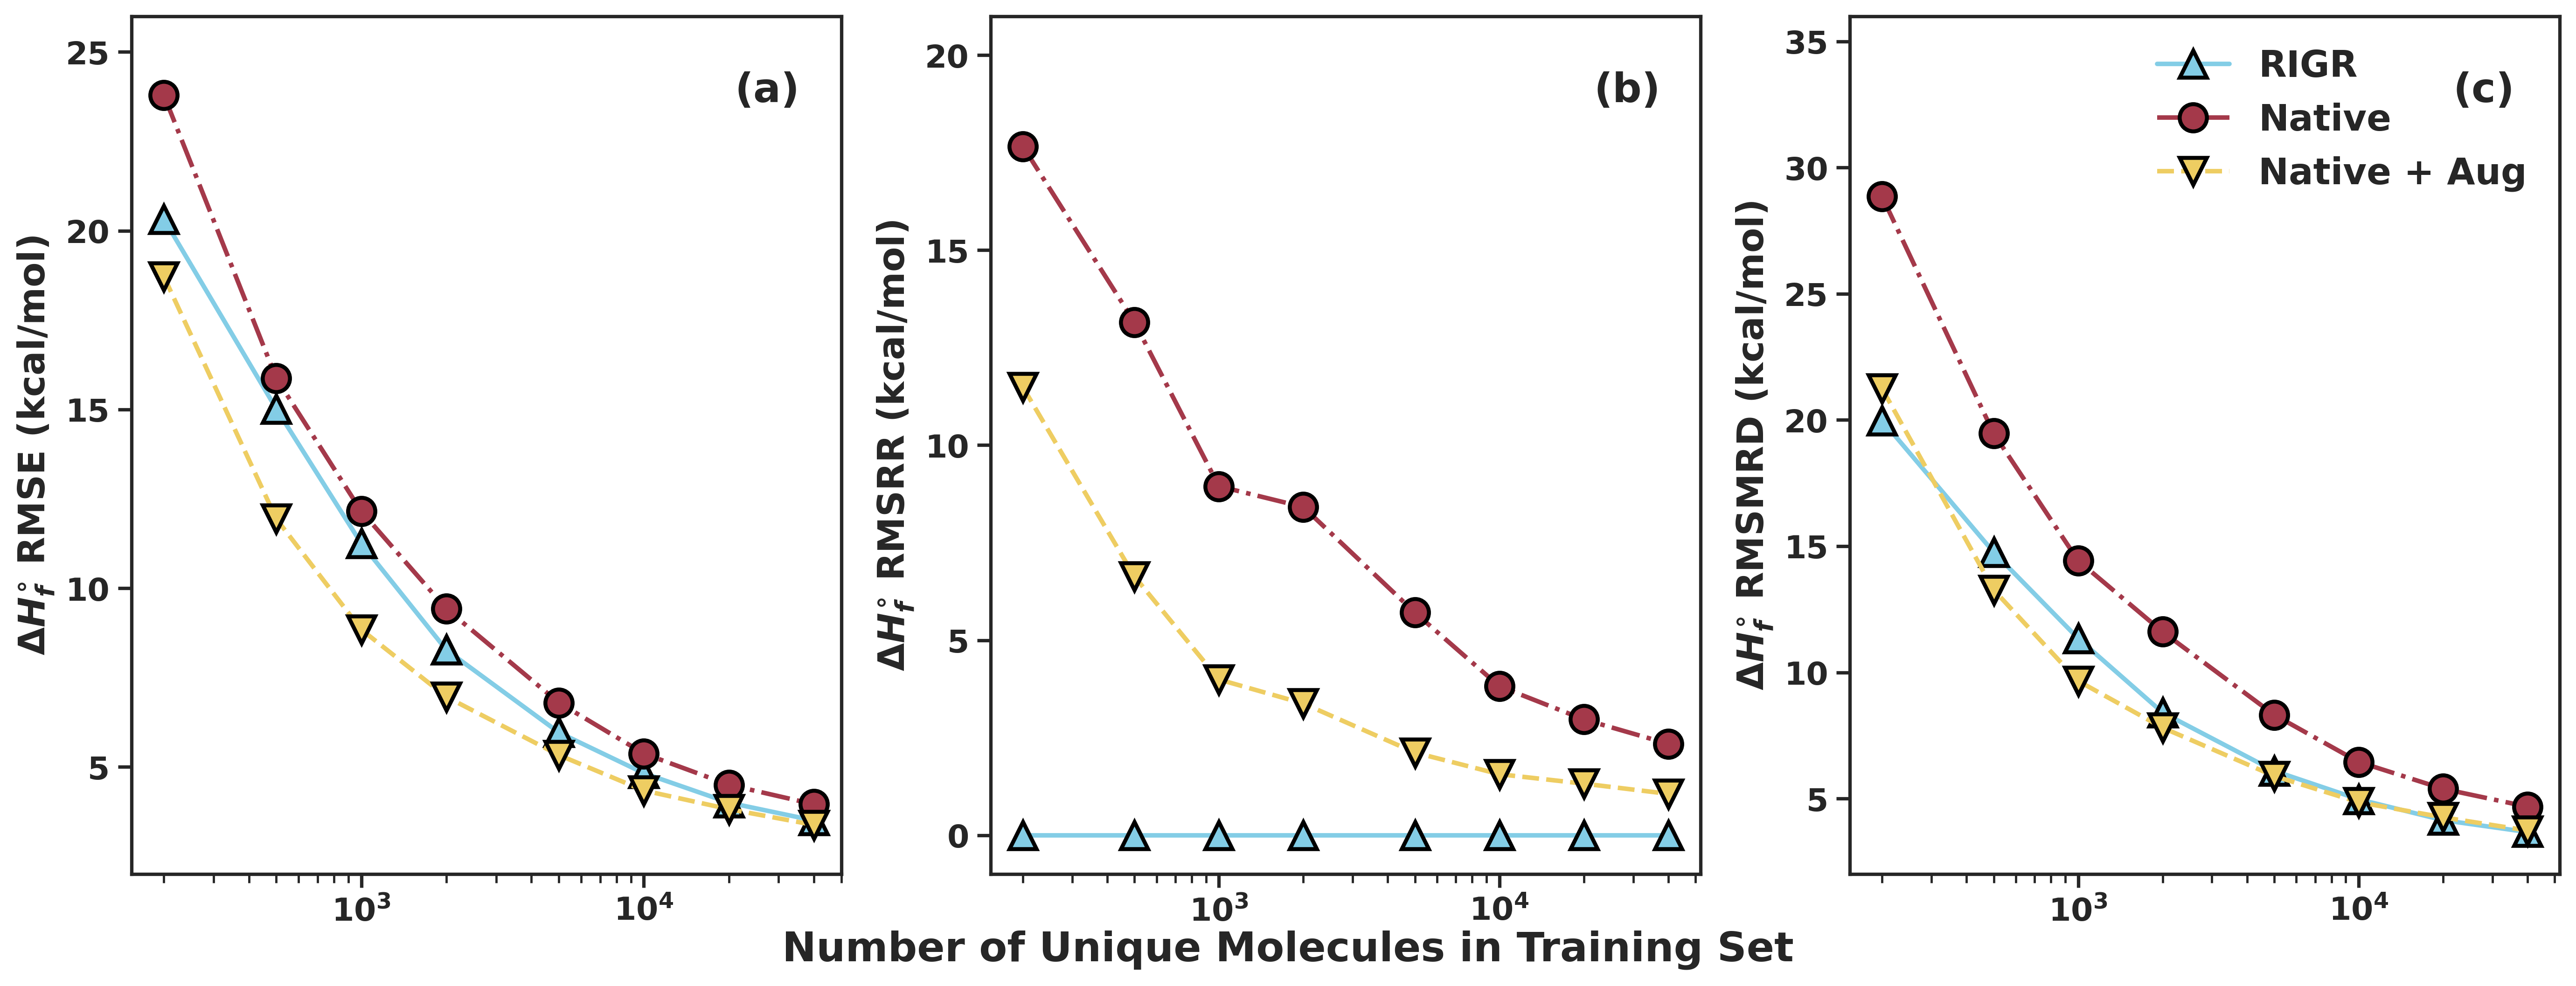

In [40]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 6), dpi=350)
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1])  # Change the width ratios as needed

plt.rcParams['font.size'] = 14
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.weight'] = 'bold'
# Create subplots and assign them to the grid spec
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

y_values_1 = downsample_rmse_run1_bof_aug
sns.lineplot(x=x_values, y=y_values_1, ax = ax1, color = my_blue, marker='^', markersize=12, label='RIGR', linestyle='-', markeredgecolor='black', markeredgewidth = 1.75)

y_values_2 = downsample_rmse_run1_baseline_aug
sns.lineplot(x=x_values, y=y_values_2, ax = ax1, color = my_red, marker='o', label='Native', markersize=12, linestyle='-.', markeredgecolor='black', markeredgewidth = 1.75)

y_values_3 = downsample_rmse_run4_baseline_aug
sns.lineplot(x=x_values, y=y_values_3, ax = ax1, color = my_yellow, marker='v', label='Native + Aug', markersize=12, linestyle='--', markeredgecolor='black', markeredgewidth = 1.75)

ax1.legend(loc = 'upper right', frameon=False, handlelength = 2)
ax1.set_xscale('log')
ax1.set_xticks([1000, 10000], [r'$10^3$', r'$10^4$'])
# ax1.set_xlabel(r'Number of Unique Molecules in Training Set')
ax1.set_ylabel(r"$\Delta H_{f}^{\circ}$ RMSE (kcal/mol)")
# ax1.set_yticks(np.arange(0, 30, 5))
ax1.set_ylim([2, 26])
ax1.set_xlim([0, 50000])
ax1.text(0.85, 0.9, "(a)", transform=ax1.transAxes, fontsize=18)
ax1.get_legend().remove()


y_values_1 = [np.sqrt((rad**2 + cs**2) / 2) for rad, cs in zip(downsample_rmsrr_run1_bof_aug_res_rad, downsample_rmsrr_run1_bof_aug_res_cs)]
sns.lineplot(x=x_values, y=y_values_1, ax=ax2, color=my_blue, marker='^', label='RIGR', markersize=12, linestyle="-", markeredgecolor='black', markeredgewidth = 1.75)

y_values_2 = [np.sqrt((rad**2 + cs**2) / 2) for rad, cs in zip(downsample_rmsrr_run1_baseline_aug_res_rad, downsample_rmsrr_run1_baseline_aug_res_cs)]
sns.lineplot(x=x_values, y=y_values_2, ax=ax2, color=my_red, marker='o', label='Native', markersize=12, linestyle="-.", markeredgecolor='black', markeredgewidth = 1.75)

y_values_3 = [np.sqrt((rad**2 + cs**2) / 2) for rad, cs in zip(downsample_rmsrr_run4_baseline_aug_res_rad, downsample_rmsrr_run4_baseline_aug_res_cs)]
sns.lineplot(x=x_values, y=y_values_3, ax=ax2, color=my_yellow, marker='v', label='Native + Aug', markersize=12, linestyle="--", markeredgecolor='black', markeredgewidth = 1.75)

ax2.set_xscale('log', base=10)
ax2.set_xticks([1000, 10000], [r'$10^3$', r'$10^4$'])
# ax2.set_xlabel('Number of Unique Molecules in Training Set')
ax2.set_ylabel(r"$\Delta H_{f}^{\circ}$ RMSRR (kcal/mol)")
ax2.set_ylim([-1, 21])
ax2.set_yticks(np.arange(0,25,5))
ax2.text(0.85, 0.9, "(b)", transform=ax2.transAxes, fontsize=18)
ax2.get_legend().remove()

y_values_1 = [np.sqrt((rad**2 + cs**2) / 2) for rad, cs in zip(downsample_rmsmrd_run1_bof_aug_res_rad, downsample_rmsmrd_run1_bof_aug_res_cs)]
sns.lineplot(x=x_values, y=y_values_1, ax=ax3, color=my_blue, marker='^', label='RIGR', markersize=12, linestyle="-", markeredgecolor='black', markeredgewidth = 1.75)

y_values_2 = [np.sqrt((rad**2 + cs**2) / 2) for rad, cs in zip(downsample_rmsmrd_run1_baseline_aug_res_rad, downsample_rmsmrd_run1_baseline_aug_res_cs)]
sns.lineplot(x=x_values, y=y_values_2, ax=ax3, color=my_red, marker='o', label='Native', markersize=12, linestyle="-.", markeredgecolor='black', markeredgewidth = 1.75)

y_values_3 = [np.sqrt((rad**2 + cs**2) / 2) for rad, cs in zip(downsample_rmsmrd_run4_baseline_aug_res_rad, downsample_rmsmrd_run4_baseline_aug_res_cs)]
sns.lineplot(x=x_values, y=y_values_3, ax=ax3, color=my_yellow, marker='v', label='Native + Aug', markersize=12, linestyle="--", markeredgecolor='black', markeredgewidth = 1.75)

ax3.set_xscale('log', base=10)
ax3.set_xticks([1000, 10000], [r'$10^3$', r'$10^4$'])
# ax3.set_xlabel('Number of Unique Molecules in Training Set')
ax3.set_ylabel(r"$\Delta H_{f}^{\circ}$ RMSMRD (kcal/mol)")
ax3.set_ylim([2, 36])
ax3.text(0.85, 0.90, "(c)", transform=ax3.transAxes, fontsize=18)
ax3.legend(loc = 'upper right', frameon=False, handlelength = 2)

# fig.set_size_inches(16, 6)
fig.text(0.5, 0.00025, 'Number of Unique Molecules in Training Set', ha='center', fontsize=18)
fig.subplots_adjust(bottom=0.3)
fig.tight_layout()

fig.savefig("/home/akshatz/bond_order_free/figures/downsample_results.pdf", bbox_inches="tight")

In [41]:
fig, ax2 = plt.subplots(ncols=1, figsize = (6,6), dpi=2700)

y_values_1 = [np.sqrt((rad**2 + cs**2) / 2) for rad, cs in zip(downsample_rmsrr_run1_bof_aug_res_rad, downsample_rmsrr_run1_bof_aug_res_cs)]
sns.lineplot(x=x_values, y=y_values_1, ax=ax2, color='#73B5BF', marker='o',markeredgewidth=0, label='RIGR', markersize=15, linestyle="-", linewidth=3.5)

y_values_2 = [np.sqrt((rad**2 + cs**2) / 2) for rad, cs in zip(downsample_rmsrr_run1_baseline_aug_res_rad, downsample_rmsrr_run1_baseline_aug_res_cs)]
sns.lineplot(x=x_values, y=y_values_2, ax=ax2, color=my_red, marker='o',markeredgewidth=0, label='Native', markersize=15, linestyle="-",  linewidth=3.5)

y_values_3 = [np.sqrt((rad**2 + cs**2) / 2) for rad, cs in zip(downsample_rmsrr_run4_baseline_aug_res_rad, downsample_rmsrr_run4_baseline_aug_res_cs)]
sns.lineplot(x=x_values, y=y_values_3, ax=ax2, color='#D8A448', marker='o',markeredgewidth=0, label='Native + Aug', markersize=15, linestyle="-",  linewidth=3.5)

ax2.set_xscale('log', base=10)
# ax2.set_xticks([1000, 10000], [r'$10^3$', r'$10^4$'])
# ax2.set_xlabel('Number of Unique Molecules in Training Set')
# ax2.set_ylabel(r"$\Delta H_{f}^{\circ}$ RMSRR (kcal/mol)")
ax2.set_ylim([-1, 21])
# ax2.set_yticks(np.arange(0,25,5))
ax2.get_legend().remove()
ax2.set_xticks([])
ax2.set_yticks([])


# # Remove top and right spines
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['bottom'].set_visible(False)

# # Move x and y axes to the center and add arrows
# ax2.spines['left'].set_position(('data', 0))
# ax2.spines['bottom'].set_position(('data', 0))
# ax2.spines['left'].set_linewidth(1.5)
# ax2.spines['bottom'].set_linewidth(1.5)

# # Hide default ticks
# ax2.xaxis.set_ticks_position('none')
# ax2.yaxis.set_ticks_position('none')

# Add arrowheads
# ax2.plot(1.02 * max(x_values), 0, ">k", transform=ax2.get_xaxis_transform(), clip_on=False)
# ax2.plot(0, 1.02 * max(y_values_1), "^k", transform=ax2.get_yaxis_transform(), clip_on=False)

fig.tight_layout()
fig.savefig('/home/akshatz/bond_order_free/figures/toc_rmsrr.svg', format='svg', transparent=True)
# fig.savefig("/home/akshatz/bond_order_free/figures/f7a.pdf", bbox_inches="tight")

/tmp/ipykernel_670298/52343515.py:21: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  axs.set_xlim([0, 50000])


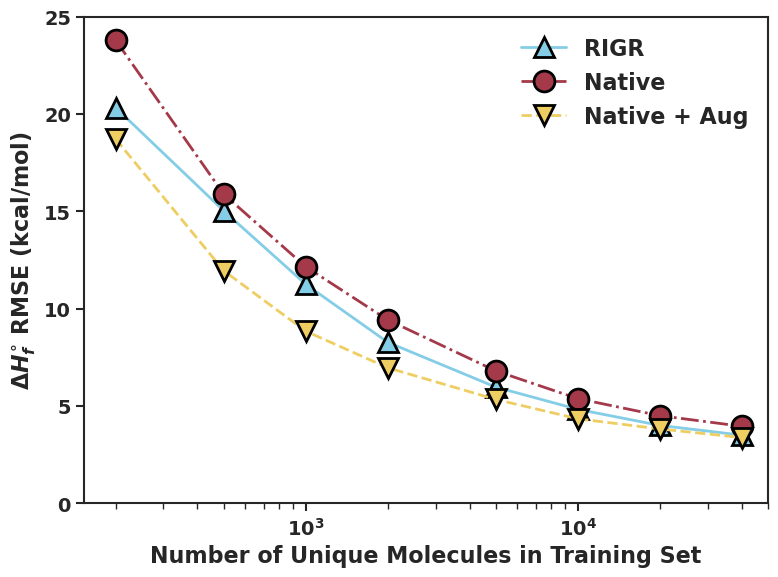

In [42]:
fig, axs = plt.subplots(ncols=1, figsize = (8,6))

y_values_1 = downsample_rmse_run1_bof_aug
sns.lineplot(x=x_values, y=y_values_1, ax = axs, color = my_blue, marker='^', markersize=15, label='RIGR', linestyle='-', markeredgecolor='black', markeredgewidth = 2)

y_values_2 = downsample_rmse_run1_baseline_aug
sns.lineplot(x=x_values, y=y_values_2, ax = axs, color = my_red, marker='o', label='Native', markersize=15, linestyle='-.', markeredgecolor='black', markeredgewidth = 2)

y_values_3 = downsample_rmse_run4_baseline_aug
sns.lineplot(x=x_values, y=y_values_3, ax = axs, color = my_yellow, marker='v', label='Native + Aug', markersize=15, linestyle='--', markeredgecolor='black', markeredgewidth = 2)

axs.legend(loc = 'upper right', frameon=False, handlelength = 2)
# axs.get_legend().remove()

axs.set_xscale('log')
axs.set_xticks([1000, 10000], [r'$10^3$', r'$10^4$'])
axs.set_xlabel(r'Number of Unique Molecules in Training Set')
axs.set_ylabel(r"$\Delta H_{f}^{\circ}$ RMSE (kcal/mol)")
axs.set_yticks(np.arange(0, 30, 5))
axs.set_ylim([0, 25])
axs.set_xlim([0, 50000])

fig.tight_layout()
# fig.savefig("/home/akshatz/bond_order_free/figures/f7a.pdf", bbox_inches="tight")

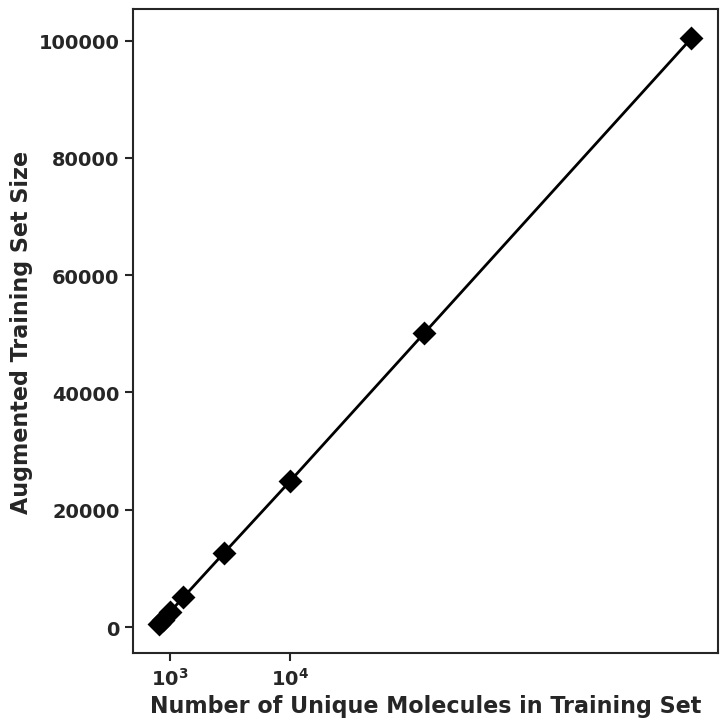

In [43]:
fig, axs = plt.subplots(ncols=1, figsize = (7.5,7.5))

x_val = [40000, 20000, 10000, 5000, 2000, 1000, 500, 200]
y_val = [100415, 50085, 24923, 12548, 5077, 2573, 1273, 502]
sns.lineplot(x=x_val, y=y_val, ax = axs, color = 'black', marker='D', markersize=10, linestyle='-', markeredgecolor='black', markeredgewidth = 2)


# axs.set_xscale('log')
# axs.set_yscale('log')
axs.set_xticks([1000, 10000], [r'$10^3$', r'$10^4$'])
axs.set_xlabel(r'Number of Unique Molecules in Training Set')
axs.set_ylabel(r'Augmented Training Set Size')

fig.tight_layout()
# fig.savefig("/home/akshatz/bond_order_free/figures/f7a_inset.pdf", bbox_inches="tight")

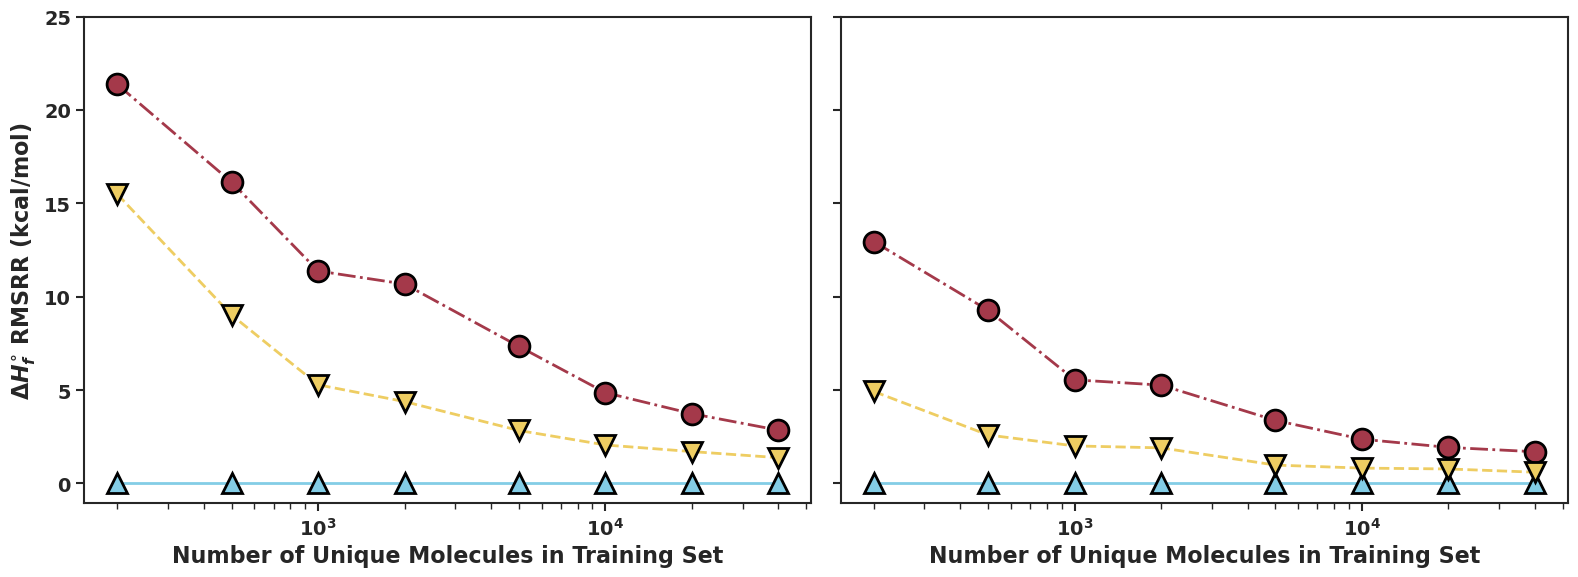

In [44]:
fig, (ax1,ax2) = plt.subplots(ncols=2, nrows=1, figsize=(16, 6), sharey=True)

# First subplot (Top-left)
y_values_1 = downsample_rmsrr_run1_bof_aug_res_rad
sns.lineplot(x=x_values, y=y_values_1, ax=ax1, color=my_blue, marker='^', label='RIGR', markersize=15, linestyle="-", markeredgecolor='black', markeredgewidth = 2)

y_values_2 = downsample_rmsrr_run1_baseline_aug_res_rad
sns.lineplot(x=x_values, y=y_values_2, ax=ax1, color=my_red, marker='o', label='Native', markersize=15, linestyle="-.", markeredgecolor='black', markeredgewidth = 2)

y_values_3 = downsample_rmsrr_run4_baseline_aug_res_rad
sns.lineplot(x=x_values, y=y_values_3, ax=ax1, color=my_yellow, marker='v', label='Native + Aug', markersize=15, linestyle="--", markeredgecolor='black', markeredgewidth = 2)

ax1.set_xscale('log', base=10)
ax1.set_xticks([1000, 10000], [r'$10^3$', r'$10^4$'])
ax1.set_xlabel('Number of Unique Molecules in Training Set')
ax1.set_ylabel(r"$\Delta H_{f}^{\circ}$ RMSRR (kcal/mol)")
ax1.get_legend().remove()

# Third subplot (Top-Right)
y_values_1 = downsample_rmsrr_run1_bof_aug_res_cs
sns.lineplot(x=x_values, y=y_values_1, ax=ax2, color=my_blue, marker='^', label='RIGR', markersize=15, linestyle="-", markeredgecolor='black', markeredgewidth = 2)

y_values_2 = downsample_rmsrr_run1_baseline_aug_res_cs
sns.lineplot(x=x_values, y=y_values_2, ax=ax2, color=my_red, marker='o', label='Native', markersize=15, linestyle="-.", markeredgecolor='black', markeredgewidth = 2)

y_values_3 = downsample_rmsrr_run4_baseline_aug_res_cs
sns.lineplot(x=x_values, y=y_values_3, ax=ax2, color=my_yellow, marker='v', label='Native + Aug', markersize=15, linestyle="--", markeredgecolor='black', markeredgewidth = 2)

ax2.set_xscale('log', base=10)
ax2.set_xticks([1000, 10000], [r'$10^3$', r'$10^4$'])
ax2.set_xlabel('Number of Unique Molecules in Training Set')
ax1.set_yticks(np.arange(0, 30, 5))
# ax2.legend(loc = 'upper right', frameon=False, handlelength = 2)
ax2.get_legend().remove()

fig.tight_layout()
# fig.savefig("/home/akshatz/bond_order_free/figures/f7b.pdf", bbox_inches="tight")

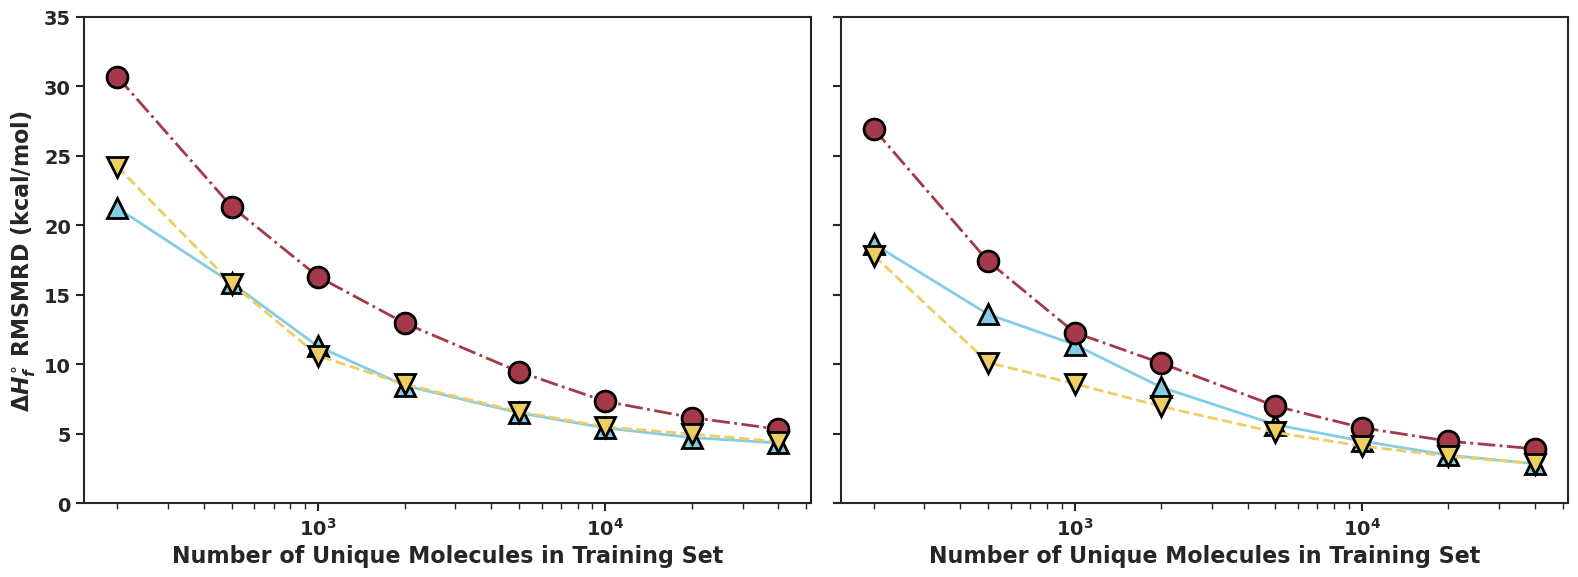

In [45]:
fig, (ax1,ax2) = plt.subplots(ncols=2, nrows=1, figsize=(16, 6), sharey=True)

# First subplot (Top-left)
y_values_1 = downsample_rmsmrd_run1_bof_aug_res_rad
sns.lineplot(x=x_values, y=y_values_1, ax=ax1, color=my_blue, marker='^', label='RIGR', markersize=15, linestyle="-", markeredgecolor='black', markeredgewidth = 2)

y_values_2 = downsample_rmsmrd_run1_baseline_aug_res_rad
sns.lineplot(x=x_values, y=y_values_2, ax=ax1, color=my_red, marker='o', label='Native', markersize=15, linestyle="-.", markeredgecolor='black', markeredgewidth = 2)

y_values_3 = downsample_rmsmrd_run4_baseline_aug_res_rad
sns.lineplot(x=x_values, y=y_values_3, ax=ax1, color=my_yellow, marker='v', label='Native + Aug', markersize=15, linestyle="--", markeredgecolor='black', markeredgewidth = 2)

ax1.set_xscale('log', base=10)
ax1.set_xticks([1000, 10000], [r'$10^3$', r'$10^4$'])
ax1.set_xlabel('Number of Unique Molecules in Training Set')
ax1.set_ylabel(r"$\Delta H_{f}^{\circ}$ RMSMRD (kcal/mol)")
ax1.get_legend().remove()

# Third subplot (Top-Right)
y_values_1 = downsample_rmsmrd_run1_bof_aug_res_cs
sns.lineplot(x=x_values, y=y_values_1, ax=ax2, color=my_blue, marker='^', label='RIGR', markersize=15, linestyle="-", markeredgecolor='black', markeredgewidth = 2)

y_values_2 = downsample_rmsmrd_run1_baseline_aug_res_cs
sns.lineplot(x=x_values, y=y_values_2, ax=ax2, color=my_red, marker='o', label='Native', markersize=15, linestyle="-.", markeredgecolor='black', markeredgewidth = 2)

y_values_3 = downsample_rmsmrd_run4_baseline_aug_res_cs
sns.lineplot(x=x_values, y=y_values_3, ax=ax2, color=my_yellow, marker='v', label='Native + Aug', markersize=15, linestyle="--", markeredgecolor='black', markeredgewidth = 2)

ax2.set_xscale('log', base=10)
ax2.set_xticks([1000, 10000], [r'$10^3$', r'$10^4$'])

ax2.set_xlabel('Number of Unique Molecules in Training Set')
# ax2.legend(loc = 'upper right', frameon=False, handlelength = 2)
ax1.set_yticks(np.arange(0, 40, 5))
ax2.get_legend().remove()
fig.tight_layout()
# fig.savefig("/home/akshatz/bond_order_free/figures/f7c.pdf", bbox_inches="tight")

# Misc

In [46]:

all_aug_data_az = pd.read_csv("/home/akshatz/bond_order_free/rigr_h298_50k/dataset/all_aug_data_set.csv")

In [47]:
my_lst = all_aug_data_az.query('num_resonance_structures == 4 and multiplicity == 2 and num_heavy_atoms <=8 and num_aromatic_rings == 1 and num_rings == 1')["resonance_smis"]

In [48]:
my_lst_2 = all_aug_data_az.query('num_resonance_structures >= 4 and multiplicity == 2 and num_heavy_atoms <=7 and num_aromatic_rings == 1 and num_rings == 1')["resonance_smis"]

In [49]:
my_lst_2

7162          [CH2]c1c[nH]nn1
7163      [CH2]c1c[nH+][n-]n1
7164            C=C1[CH]NN=N1
7165      C=C1C=[NH+][N-][N]1
8015            C=C1ON=N[C]1C
                 ...         
105716    [CH2]c1nc[nH+][n-]1
105717        [CH2]c1nc[nH]n1
105718           C=C1[N]NC=N1
105719    C=C1[N]C=[NH+][N-]1
105720      C=C1N=C[NH+][N-]1
Name: resonance_smis, Length: 208, dtype: object

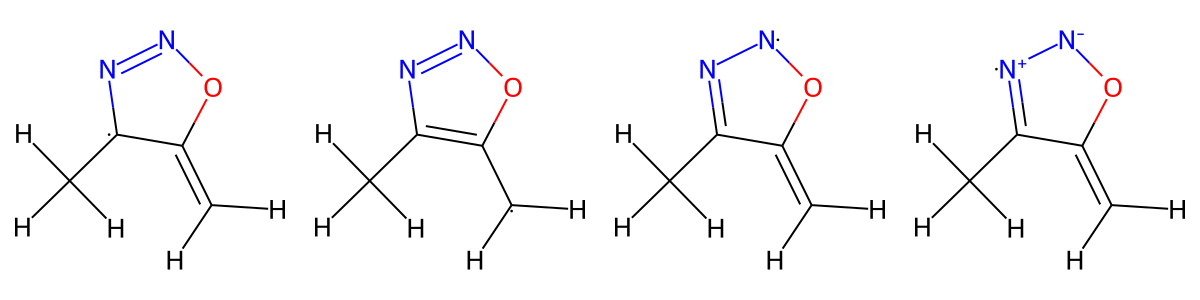

In [50]:
my_lst_2_dummy = my_lst_2.loc[8015:8019]

from rdkit import Chem
from rdkit.Chem import Draw


# Convert SMILES to molecules and add hydrogens
mols_with_hs = [Chem.AddHs(Chem.MolFromSmiles(smi)) for smi in my_lst_2_dummy if Chem.MolFromSmiles(smi)]

# Generate the grid image (2x2 grid or customize)
grid_img = Draw.MolsToGridImage(mols_with_hs, molsPerRow=4, subImgSize=(300, 300))

# Display the grid image
grid_img

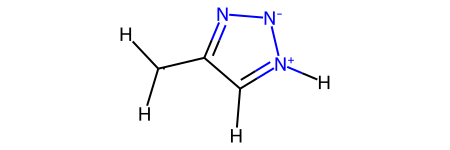

In [51]:
smi = '[CH2]c1c[nH+][n-]n1'
mol = Chem.AddHs(Chem.MolFromSmiles(smi))
display(mol)

In [52]:
my_lst

6243             [CH2]n1cc(N)c(C)n1
6244       C=[N+]1C=C(N)[C](C)[N-]1
6245      C=[N+]1[CH]C(N)=C(C)[N-]1
6246       [CH2][n+]1cc(N)c(C)[n-]1
7162                [CH2]c1c[nH]nn1
                    ...            
120610        C[CH][n+]1cc(N)c[n-]1
121778      [CH2]c1c[n-][n+](C=O)c1
121779           C=C1[CH]N(C=O)N=C1
121780            [CH2]c1cnn(C=O)c1
121781     C=C1[CH][N-][N+](C=O)=C1
Name: resonance_smis, Length: 412, dtype: object

In [53]:
my_lst.iloc[32]

'[CH2]c1coc([NH-])[nH+]1'

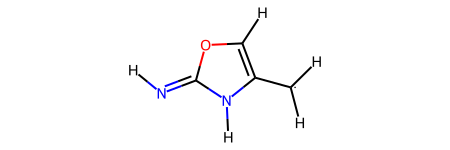

In [54]:
smi = my_lst.iloc[33]
mol = Chem.AddHs(Chem.MolFromSmiles(smi))
display(mol)

In [55]:
smi

'[CH2]c1coc(=N)[nH]1'

/home/akshatz/anaconda3/envs/dftdb_env/lib/python3.9/site-packages/rdkit/Chem/Draw/IPythonConsole.py:261: UserWarning: Truncating the list of molecules to be displayed to 50. Change the maxMols value to display more.
  warnings.warn(


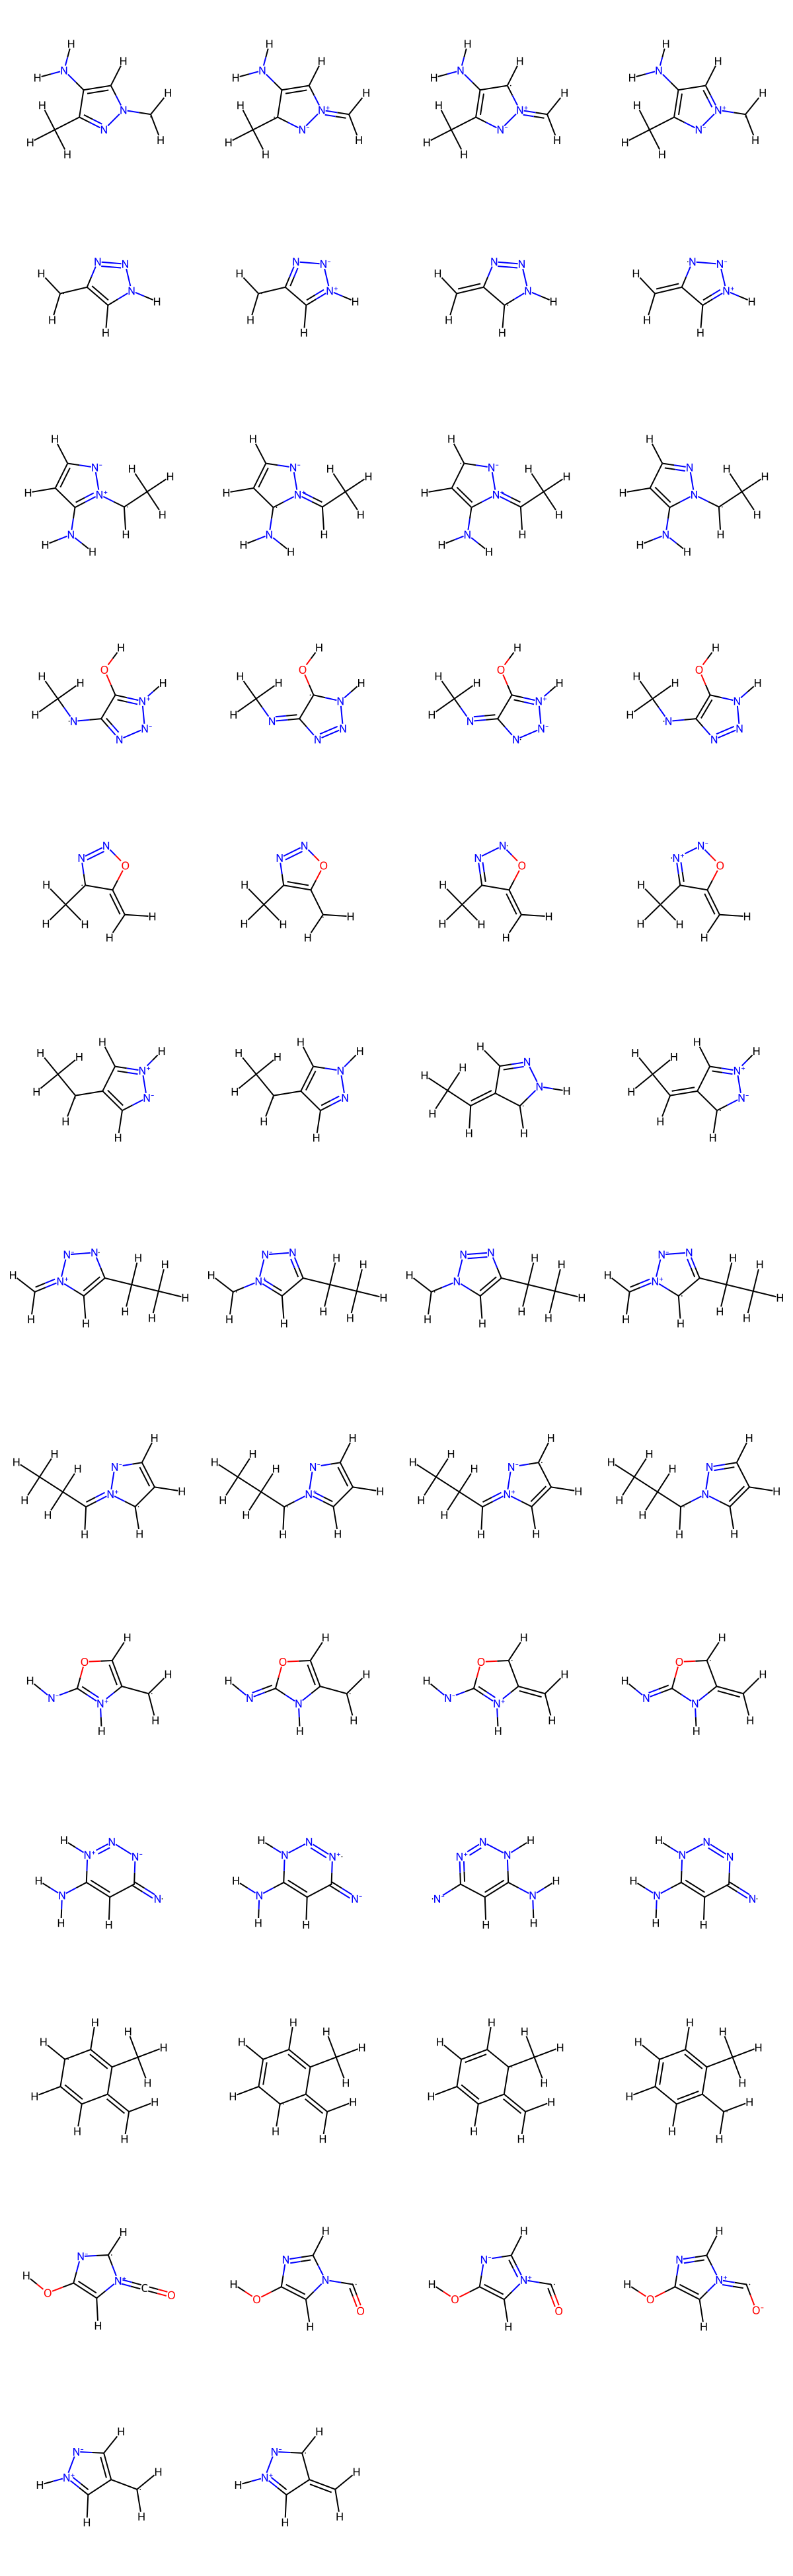

In [56]:
from rdkit import Chem
from rdkit.Chem import Draw


# Convert SMILES to molecules and add hydrogens
mols_with_hs = [Chem.AddHs(Chem.MolFromSmiles(smi)) for smi in my_lst if Chem.MolFromSmiles(smi)]

# Generate the grid image (2x2 grid or customize)
grid_img = Draw.MolsToGridImage(mols_with_hs, molsPerRow=4, subImgSize=(300, 300))

# Display the grid image
grid_img
